In [14]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit, njit, prange
import warnings
warnings.filterwarnings('ignore')

In [15]:
class GridWorld:
    def __init__(self, size, start, goal_state, obstacle_states, trap_state, seed):
        self.size = size
        self.goal = goal_state
        self.obstacles = obstacle_states
        self.trap = trap_state
        self.state = None
        self.seed = seed
        self.start=start
        np.random.seed(seed)

    def reset(self):
        self.state = self.start  # Start state

    def step(self, action):

        current_state = self.state

        if action == 'N':
            next_state = [self.state[0] - 1, self.state[1]]
        elif action == 'S':
            next_state = [self.state[0] + 1, self.state[1]]
        elif action == 'E':
            next_state = [self.state[0], self.state[1] + 1]
        elif action == 'W':
            next_state = [self.state[0], self.state[1] - 1]
        else:
            raise ValueError("Invalid action")

        # Check if the next state is valid
        if self.is_valid_state(next_state):
            self.state = next_state
            reward = self.get_reward(self.state)
        else:
            reward = self.get_reward(next_state)

        is_terminal = self.is_terminal_state(next_state)



        return self.state, reward, is_terminal

    def is_valid_state(self, state):
        row, col = state
        # Check if within valid grid boundaries and not in obstacles
        if (1 <= row <= self.size) and (1 <= col <= self.size) and ([row, col] not in self.obstacles):
            return True
        return False

    def is_terminal_state(self, state):
        # Check if the state is the goal state
        if state == self.goal or state == self.trap:
            return True
        return False

    def get_reward(self, state):
        # Return the reward for the given state
        if state == self.goal:
            return 5  # Goal reward
        elif state == self.trap:
            return -5
        elif (state[0] < 1) or (state[1] < 1) or (state[0] > self.size) or (state[1] > self.size):
            return -1 # Out of Bounds reward
        else:
            return 0

    def plot_grid(self, policy=None, plot_policy_flag=False):
        plt.figure()
        ax = plt.gca()

        # Plot gridlines
        for i in range(1, self.size):
            ax.axhline(i, color='k', linestyle='-', linewidth=1)
            ax.axvline(i, color='k', linestyle='-', linewidth=1)

        ax.plot(self.start[1] - 0.5, self.start[0] - 0.5, 'bo', markerfacecolor='b', markersize=20)
        # Plot goal state
        ax.plot(self.goal[1] - 0.5, self.goal[0] - 0.5, 'gs', markerfacecolor='g', markersize=30)

        # Plot obstacles
        for obstacle in self.obstacles:
            ax.plot(obstacle[1] - 0.5, obstacle[0] - 0.5, 'ks', markerfacecolor='k', markersize=30)

        # Plot Trap
        ax.plot(self.trap[1] - 0.5, self.trap[0] - 0.5, 'rs', markerfacecolor='r', markersize=30)

        # Plot current state
        ax.plot(self.state[1] - 0.5, self.state[0] - 0.5, 'ro', markerfacecolor='r', markersize=20)

        if plot_policy_flag and policy is not None:
            self.plot_policy_arrows(policy, self.start)

        ax.set_xlim([0, self.size])
        ax.set_ylim([self.size, 0])
        ax.set_xticks(np.arange(self.size))
        ax.set_yticks(np.arange(self.size))
        ax.grid(True)
        ax.set_aspect('equal')
        plt.show()

    def plot_policy_arrows(self, policy, start):
        for i in range(self.size):
            for j in range(self.size):
                if [i + 1, j + 1] != self.goal and [i + 1, j + 1] != self.trap and [i + 1, j + 1] not in self.obstacles:
                    action = policy[i, j]
                    if action == 0:  # North
                        dx, dy = 0, -0.3
                    elif action == 1:  # South
                        dx, dy = 0, 0.3
                    elif action == 2:  # East
                        dx, dy = 0.3, 0
                    elif action == 3:  # West
                        dx, dy = -0.3, 0
                    else:
                        continue

                    plt.arrow(j + 0.5, i + 0.5, dx, dy, head_width=0.1, head_length=0.1, fc='k', ec='k')
                    plt.title('Converged Policy')


In [16]:
class BridgeGridWorld(GridWorld):
    def __init__(self, size, start, goal_state, obstacle_states, trap_state, seed, bridge_state):
        super().__init__(size, start, goal_state, obstacle_states, trap_state, seed)
        self.bridge_state = bridge_state
        self.bridge_col = bridge_state[1]
        self.total_cols = size * 2 + 1

        # Override size to represent total number of columns for state calculations
        self.grid_rows = self.size  # Keep original rows
        self.grid_cols = self.total_cols  # Total columns including bridge

        # Explicitly define wall coordinates (entire bridge column except bridge)
        self.walls = [[r, self.bridge_col] for r in range(1, self.grid_rows + 1)
                      if [r, self.bridge_col] != self.bridge_state]

    def is_valid_state(self, state):
        row, col = state

        if (1 <= row <= self.grid_rows) and (1 <= col <= self.grid_cols) and (state not in self.walls) and (state not in self.obstacles):
            return True
        return False

    def get_reward(self, state):
        if state == self.goal:
            return 5  # Goal reward
        elif state == self.trap:
            return -5
        elif (state[0] < 1) or (state[1] < 1) or (state[0] > self.grid_rows) or (state[1] > self.grid_cols) or (state in self.walls):
            return -1
        else:
            return 0

    def plot_grid(self, policy=None, plot_policy_flag=False):
        """
        Extend plotter to show explicit wall column (bridge col walls).
        """
        plt.figure(figsize=(8, 5))
        ax = plt.gca()
        total_size = self.grid_cols

        # Draw gridlines
        for i in range(1, total_size):
            ax.axhline(i, color='gray', linestyle='-', linewidth=0.5)
            ax.axvline(i, color='gray', linestyle='-', linewidth=0.5)

        # Start, goal, trap
        ax.plot(self.start[1] - 0.5, self.start[0] - 0.5, 'bo', markersize=20, label='Start')
        ax.plot(self.goal[1] - 0.5, self.goal[0] - 0.5, 'gs', markersize=25, label='Goal')
        ax.plot(self.trap[1] - 0.5, self.trap[0] - 0.5, 'rs', markersize=25, label='Trap')

        # Obstacles (black)
        for obs in self.obstacles:
            ax.plot(obs[1] - 0.5, obs[0] - 0.5, 'ks', markersize=25)

        # Bridge walls (gray)
        for wall in self.walls:
            ax.plot(wall[1] - 0.5, wall[0] - 0.5, 's', color='lightgray', markersize=25)

        # Current state
        ax.plot(self.state[1] - 0.5, self.state[0] - 0.5, 'mo', markersize=15)

        # Optional policy arrows
        if plot_policy_flag and policy is not None:
            self.plot_policy_arrows(policy, self.start)

        ax.set_xlim([0, total_size])
        ax.set_ylim([self.grid_rows, 0])
        ax.set_xticks(np.arange(total_size))
        ax.set_yticks(np.arange(self.grid_rows))
        ax.grid(True)
        ax.set_aspect('equal')
        plt.title("Bridge GridWorld")
        plt.show()

    def plot_policy_arrows(self, policy, start):
        """Override to handle the larger grid dimensions."""
        for i in range(self.grid_rows):
            for j in range(self.grid_cols):
                state_pos = [i + 1, j + 1]
                # Skip goal, trap, obstacles, and walls
                if (state_pos != self.goal and state_pos != self.trap and
                    state_pos not in self.obstacles and state_pos not in self.walls):

                    action = policy[i, j]
                    if action == 0:  # North
                        dx, dy = 0, -0.3
                    elif action == 1:  # South
                        dx, dy = 0, 0.3
                    elif action == 2:  # East
                        dx, dy = 0.3, 0
                    elif action == 3:  # West
                        dx, dy = -0.3, 0
                    else:
                        continue

                    plt.arrow(j + 0.5, i + 0.5, dx, dy, head_width=0.1, head_length=0.1, fc='k', ec='k')
        plt.title('Converged Policy')


In [ ]:
@njit
def q_update(Q, current_state, action_idx, alpha, reward, gamma, next_state):
    """Numba-optimized Q-table update."""
    max_next_q = np.max(Q[next_state - 1, :])
    td_error = reward + gamma * max_next_q - Q[current_state - 1, action_idx]
    Q[current_state - 1, action_idx] += alpha * td_error
    return Q

@njit
def epsilon_greedy(Q, state, epsilon, num_actions):
    """Numba-optimized epsilon-greedy action selection."""
    if np.random.rand() < epsilon:
        return np.random.randint(0, num_actions)
    else:
        return np.argmax(Q[state - 1, :])

@njit
def softmax_action(Q, state, epsilon, num_actions):
    """Numba-optimized softmax action selection."""
    q_values = Q[state - 1, :]
    max_q = np.max(q_values)
    exp_q = np.exp(epsilon * (q_values - max_q))
    # scaled_q = q_values / epsilon
    # stable_q = scaled_q - np.max(scaled_q)
    # exp_q = np.exp(stable_q)

    probs = exp_q / np.sum(exp_q)
    
    cumsum = np.cumsum(probs)
    rand_val = np.random.rand()
    for i in range(num_actions):
        if rand_val <= cumsum[i]:
            return i
    return num_actions - 1

@njit
def get_state_index(row, col, grid_cols):
    """Numba-optimized state index calculation."""
    return (row - 1) * grid_cols + col

@njit
def train_episode_epsilon_greedy(Q, alpha, gamma, epsilon, num_actions, max_steps,
                                  initial_state_coords, goal_coords, trap_coords,
                                  grid_size, grid_cols):
    """Numba-optimized training for a single episode with epsilon-greedy."""
    current_state = get_state_index(np.int32(initial_state_coords[0]), 
                                          np.int32(initial_state_coords[1]), grid_cols)
    
    episode_reward = 0.0
    episode_steps = 0
    episode_outcome = 0  # 0=timeout, 1=goal, 2=trap
    
    # Create action map: 0=N, 1=S, 2=E, 3=W as deltas
    action_deltas = np.array([[-1, 0], [1, 0], [0, 1], [0, -1]], dtype=np.int32)
    
    # Current coordinates - explicitly typed
    current_row = np.int32(initial_state_coords[0])
    current_col = np.int32(initial_state_coords[1])
    
    for step in range(max_steps):
        # Select action
        action_idx = epsilon_greedy(Q, current_state, epsilon, num_actions)
        
        # Apply action (move in environment)
        delta = action_deltas[action_idx]
        attempted_row = current_row + delta[0]
        attempted_col = current_col + delta[1]
        
        # Boundary check and reward calculation
        if (attempted_row < 1 or attempted_row > grid_size or 
            attempted_col < 1 or attempted_col > grid_size):
            # Out of bounds - stay in place, get penalty
            next_row = current_row
            next_col = current_col
            reward = -1.0
        else:
            # Valid move - agent moves to new position
            next_row = attempted_row
            next_col = attempted_col
            reward = 0.0  # Default reward for valid non-terminal move
        
        # Get next state
        next_state = get_state_index(next_row, next_col, grid_cols)
        
        # Check for terminal states and override reward if needed
        is_terminal = False
        
        if next_row == goal_coords[0] and next_col == goal_coords[1]:
            reward = 5.0
            is_terminal = True
            episode_outcome = 1
        elif next_row == trap_coords[0] and next_col == trap_coords[1]:
            reward = -5.0
            is_terminal = True
            episode_outcome = 2
        
        # Update Q-table
        Q = q_update(Q, current_state, action_idx, alpha, reward, gamma, next_state)
        
        # Update for next iteration
        current_state = next_state
        current_row = next_row
        current_col = next_col
        episode_reward += reward
        episode_steps += 1
        
        if is_terminal:
            break
    
    return Q, episode_steps, episode_reward, episode_outcome


class Qlearning:
    def __init__(self, env, alpha, episodes, seed, gamma=0.9, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.episodes = episodes
        self.gamma = gamma
        self.epsilon = epsilon
        self.num_actions = 4
        
        if hasattr(env, 'grid_rows') and hasattr(env, 'grid_cols'):
            self.num_states = env.grid_rows * env.grid_cols
            self.grid_rows = env.grid_rows
            self.grid_cols = env.grid_cols
            self.max_steps = env.grid_rows * env.grid_cols * 10
        else:
            self.num_states = env.size * env.size
            self.grid_rows = env.size
            self.grid_cols = env.size
            self.max_steps = env.size * env.size * 10

        # Set random seed for reproducibility
        np.random.seed(seed)

        # Initialize Q-table with small random values
        self.Q = 0.001 * np.random.rand(self.num_states, self.num_actions)

        # Training metrics
        self.steps_per_episode = []
        self.rewards_per_episode = []
        self.success_rate_history = []
        self.episode_outcomes = []

        # Action mapping
        self.action_map = {0: 'N', 1: 'S', 2: 'E', 3: 'W'}

    def get_state(self, coordinates, grid_size):
        """Convert grid coordinates to state index."""
        if hasattr(self.env, 'grid_cols'):
            return (coordinates[0] - 1) * self.grid_cols + coordinates[1]
        else:
            return (coordinates[0] - 1) * grid_size + coordinates[1]

    def softmax_action_selection(self, state):
        """Select an action using the Softmax (Boltzmann) policy."""
        return softmax_action(self.Q, state, self.epsilon, self.num_actions)

    def epsilon_greedy_action(self, state, epsilon=None):
        """Choose action using epsilon-greedy policy."""
        if epsilon is None:
            epsilon = self.epsilon
        return epsilon_greedy(self.Q, state, epsilon, self.num_actions)

    def train(self, verbose=True, track_metrics=True, softmax=False):
        """Train the Q-learning agent with Numba optimization."""
        if verbose:
            print(f"Starting Q-learning training (Numba-optimized)...")
            print(f"Episodes: {self.episodes}, Learning Rate: {self.alpha}")
            print(f"Discount Factor: {self.gamma}, Epsilon: {self.epsilon}")
            print("-" * 60)

        # Get environment parameters as numpy arrays with correct dtypes
        initial_coords = np.array(self.env.start, dtype=np.int32)
        goal_coords = np.array(self.env.goal, dtype=np.int32)
        trap_coords = np.array(self.env.trap, dtype=np.int32)
        
        # Check if this is BridgeGridWorld
        is_bridge_env = hasattr(self.env, 'bridge_state')
        
        if is_bridge_env and softmax:
            # Prepare bridge-specific parameters
            bridge_col = self.env.bridge_col
            bridge_row = self.env.bridge_state[0]
            obstacles_flat = np.array([item for obs in self.env.obstacles for item in obs], dtype=np.int32)
            num_obstacles = len(self.env.obstacles)
        
        for episode in range(self.episodes):
            self.env.reset()
            
            if softmax and is_bridge_env:
                # Use fully optimized Numba version for BridgeGridWorld with softmax
                self.Q, episode_steps, episode_reward, outcome_code = train_episode_softmax_bridge(
                    self.Q, self.alpha, self.gamma, self.epsilon, self.num_actions,
                    self.max_steps, initial_coords, goal_coords, trap_coords,
                    self.grid_rows, self.grid_cols, bridge_col, bridge_row,
                    obstacles_flat, num_obstacles
                )
                
                # Convert outcome code to string
                if outcome_code == 1:
                    episode_outcome = 'goal'
                elif outcome_code == 2:
                    episode_outcome = 'trap'
                else:
                    episode_outcome = 'timeout'
                    
            elif softmax and not is_bridge_env:
                # For regular GridWorld with softmax, use hybrid approach
                current_state = self.get_state(self.env.state, self.env.size)
                episode_steps = 0
                episode_reward = 0
                episode_outcome = 'timeout'

                for step in range(self.max_steps):
                    action_idx = self.softmax_action_selection(current_state)
                    action = self.action_map[action_idx]

                    next_state, reward, is_terminal = self.env.step(action)
                    next_state_idx = self.get_state(next_state, self.env.size)

                    self.Q = q_update(self.Q, current_state, action_idx, 
                                           self.alpha, reward, self.gamma, next_state_idx)

                    current_state = next_state_idx
                    episode_steps += 1
                    episode_reward += reward

                    if is_terminal:
                        if self.env.state == self.env.goal:
                            episode_outcome = 'goal'
                        elif self.env.state == self.env.trap:
                            episode_outcome = 'trap'
                        break
            else:
                # Use fully optimized Numba version for epsilon-greedy
                self.Q, episode_steps, episode_reward, outcome_code = train_episode_epsilon_greedy(
                    self.Q, self.alpha, self.gamma, self.epsilon, self.num_actions,
                    self.max_steps, initial_coords, goal_coords, trap_coords,
                    self.env.size, self.grid_cols
                )
                
                # Convert outcome code to string
                if outcome_code == 1:
                    episode_outcome = 'goal'
                elif outcome_code == 2:
                    episode_outcome = 'trap'
                else:
                    episode_outcome = 'timeout'

            if track_metrics:
                self.steps_per_episode.append(int(episode_steps))
                self.rewards_per_episode.append(float(episode_reward))
                self.episode_outcomes.append(episode_outcome)

        if verbose:
            print("-" * 60)
            print("Training completed!")

        return {
            'Q_table': self.Q.copy(),
            'steps_per_episode': self.steps_per_episode,
            'rewards_per_episode': self.rewards_per_episode,
            'success_rate_history': self.success_rate_history,
            'episode_outcomes': self.episode_outcomes
        }

    def get_training_statistics(self):
        if not self.episode_outcomes:
            print("No training data available. Run train() first.")
            return None

        goal_count = self.episode_outcomes.count('goal')
        trap_count = self.episode_outcomes.count('trap')
        timeout_count = self.episode_outcomes.count('timeout')
        total_episodes = len(self.episode_outcomes)

        return {
            'total_episodes': total_episodes,
            'goal_episodes': goal_count,
            'trap_episodes': trap_count,
            'timeout_episodes': timeout_count,
            'success_rate': goal_count / total_episodes,
            'trap_rate': trap_count / total_episodes,
            'timeout_rate': timeout_count / total_episodes,
            'failure_rate': (trap_count + timeout_count) / total_episodes,
            'avg_steps': np.mean(self.steps_per_episode),
            'avg_reward': np.mean(self.rewards_per_episode),
            'total_steps': sum(self.steps_per_episode),
            'total_reward': sum(self.rewards_per_episode)
        }

    def get_policy_and_value_function(self, goal_reward=5, trap_penalty=-5):
        """Extract policy and value function from Q-table."""
        policy = np.zeros((self.grid_rows, self.grid_cols), dtype=int)
        value_function = np.zeros((self.grid_rows, self.grid_cols))

        for i in range(self.grid_rows):
            for j in range(self.grid_cols):
                state = self.get_state([i + 1, j + 1], self.env.size)

                best_action = np.argmax(self.Q[state-1, :])
                policy[i, j] = best_action

                value_function[i, j] = np.max(self.Q[state-1, :])

                if [i + 1, j + 1] == self.env.goal:
                    value_function[i, j] = goal_reward
                elif [i + 1, j + 1] == self.env.trap:
                    value_function[i, j] = trap_penalty

        return policy, value_function

    def plot_policy_and_value(self, goal_reward=5, trap_penalty=-5):
        """Plot the learned policy and value function."""
        policy, value_function = self.get_policy_and_value_function(goal_reward, trap_penalty)

        self.env.plot_grid(policy, plot_policy_flag=True)

        plt.figure(figsize=(12, 5) if self.grid_cols > self.grid_rows else (8, 6))
        plt.imshow(value_function, cmap='hot', interpolation='nearest')
        plt.colorbar(label='State Value')
        plt.title(f'Value Function (α={self.alpha}, γ={self.gamma}, β/ε={self.epsilon})')
        plt.xlabel('Columns')
        plt.ylabel('Rows')
        plt.xticks(np.arange(self.grid_cols))
        plt.yticks(np.arange(self.grid_rows))
        plt.grid(True, alpha=0.3)
        plt.show()

        return policy, value_function

    @staticmethod
    def calculate_epoch_statistics(all_steps, all_rewards):
        # Calculate average and standard deviation across epochs
        avg_steps = np.mean(all_steps, axis=0)
        std_steps = np.std(all_steps, axis=0)
        avg_rewards = np.mean(all_rewards, axis=0)
        std_rewards = np.std(all_rewards, axis=0)

        # Calculate cumulative average reward and its std
        cumulative_avg_reward = np.cumsum(avg_rewards) / np.arange(1, len(avg_rewards) + 1)

        # For cumulative std, calculate it from the cumulative sums of each epoch
        cumulative_rewards = [np.cumsum(epoch_rewards) / np.arange(1, len(epoch_rewards) + 1)
                             for epoch_rewards in all_rewards]
        std_cumulative_avg_reward = np.std(cumulative_rewards, axis=0)

        return {
            'avg_steps': avg_steps,
            'std_steps': std_steps,
            'avg_rewards': avg_rewards,
            'std_rewards': std_rewards,
            'cumulative_avg_reward': cumulative_avg_reward,
            'std_cumulative_avg_reward': std_cumulative_avg_reward
        }

    @staticmethod
    def run_multiple_epochs(env_config, alpha, episodes, gamma, epsilon_values, num_epochs=20, verbose=False):
        results = {}

        for epsilon in epsilon_values:
            if verbose:
                print(f"\n{'='*70}")
                print(f"Training with ε = {epsilon} (γ = {gamma})")
                print(f"{'='*70}")

            all_steps = []
            all_rewards = []

            for epoch in range(num_epochs):
                if verbose:
                    print(f"Epoch {epoch+1}/{num_epochs}...", end=' ')

                epoch_seed = env_config['seed'] + epoch

                # Create fresh environment and agent for each epoch
                env = GridWorld(
                    size=env_config['size'],
                    start=env_config['start'],
                    goal_state=env_config['goal_state'],
                    obstacle_states=env_config['obstacle_states'],
                    trap_state=env_config['trap_state'],
                    seed=epoch_seed
                )

                agent = Qlearning(env, alpha, episodes, seed=epoch_seed,
                                gamma=gamma, epsilon=epsilon)

                agent.train(verbose=False, track_metrics=True)

                all_steps.append(agent.steps_per_episode)
                all_rewards.append(agent.rewards_per_episode)

                if verbose:
                    print(f"Done")

            # Calculate statistics using the dedicated method
            epoch_stats = Qlearning.calculate_epoch_statistics(all_steps, all_rewards)
            results[epsilon] = epoch_stats

            if verbose:
                print(f"Completed ε = {epsilon}")

        return results
    
    @staticmethod
    def run_multiple_epochs_bridge(bridge_config, alpha, episodes, gamma, epsilon_values, num_epochs=20, verbose=False):
        results = {}

        for epsilon in epsilon_values:
            if verbose:
                print(f"\n{'='*70}")
                print(f"Training BridgeGridWorld with β = {epsilon} (γ = {gamma})")
                print(f"{'='*70}")

            all_steps = []
            all_rewards = []

            for epoch in range(num_epochs):
                if verbose:
                    print(f"Epoch {epoch+1}/{num_epochs}...", end=' ')

                # Create fresh BridgeGridWorld environment for each epoch
                epoch_seed = bridge_config['seed'] + epoch
                
                env = BridgeGridWorld(
                    size=bridge_config['size'],
                    start=bridge_config['start'],
                    goal_state=bridge_config['goal_state'],
                    obstacle_states=bridge_config['obstacle_states'],
                    trap_state=bridge_config['trap_state'],
                    seed=epoch_seed,
                    bridge_state=bridge_config['bridge_state']
                )

                # Create agent with epoch-specific seed
                agent = Qlearning(env, alpha, episodes, seed=epoch_seed,
                                gamma=gamma, epsilon=epsilon)

                # Train with softmax=True
                agent.train(verbose=False, track_metrics=True, softmax=True)

                all_steps.append(agent.steps_per_episode)
                all_rewards.append(agent.rewards_per_episode)

                if verbose:
                    print(f"Done")

            # Calculate statistics using the dedicated method
            epoch_stats = Qlearning.calculate_epoch_statistics(all_steps, all_rewards)
            results[epsilon] = epoch_stats

            if verbose:
                print(f"Completed β = {epsilon}")

        return results

    @staticmethod
    def run_single_epoch(env_config, alpha, episodes, gamma, epsilon_values, verbose=False):
        results = {}

        for epsilon in epsilon_values:
            if verbose:
                print(f"Training with ε = {epsilon} (γ = {gamma})...", end=' ')

            # Create environment and agent
            env = GridWorld(
                size=env_config['size'],
                start=env_config['start'],
                goal_state=env_config['goal_state'],
                obstacle_states=env_config['obstacle_states'],
                trap_state=env_config['trap_state'],
                seed=env_config['seed']
            )

            agent = Qlearning(env, alpha, episodes, seed=env_config['seed'],
                            gamma=gamma, epsilon=epsilon)

            agent.train(verbose=False, track_metrics=True)

            # Calculate cumulative average reward
            cumulative_avg_reward = np.cumsum(agent.rewards_per_episode) / np.arange(1, len(agent.rewards_per_episode) + 1)

            results[epsilon] = {
                'steps': np.array(agent.steps_per_episode),
                'rewards': np.array(agent.rewards_per_episode),
                'cumulative_avg_reward': cumulative_avg_reward
            }

            if verbose:
                print(f"Done")

        return results

    @staticmethod
    def plot_single_epoch_results(results, gamma, episodes):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        episode_range = np.array(range(1, episodes + 1))
        colors = ['blue', 'green', 'red']

        # Plot 1: Log Episodes vs Steps to Goal
        for idx, (epsilon, data) in enumerate(results.items()):
            ax1.plot(episode_range, data['steps'],
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)

        ax1.set_xscale('log')
        ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
        ax1.set_title(f'Steps to Goal vs Log Episodes (γ = {gamma})\nSingle Epoch Test',
                     fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)

        # Plot 2: Log Episodes vs Cumulative Average Reward
        for idx, (epsilon, data) in enumerate(results.items()):
            ax2.plot(episode_range, data['cumulative_avg_reward'],
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)

        ax2.set_xscale('log')
        ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
        ax2.set_title(f'Cumulative Average Reward vs Log Episodes (γ = {gamma})\nSingle Epoch Test',
                     fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print summary statistics
        print(f"\n{'='*70}")
        print(f"SINGLE EPOCH TEST RESULTS (γ = {gamma})")
        print(f"{'='*70}")
        for epsilon, data in results.items():
            print(f"\nε = {epsilon}:")
            print(f"  Final Steps to Goal: {data['steps'][-1]}")
            print(f"  Final Cumulative Avg Reward: {data['cumulative_avg_reward'][-1]:.4f}")
            print(f"  Mean Steps (all episodes): {np.mean(data['steps']):.2f}")
            print(f"  Mean Reward (all episodes): {np.mean(data['rewards']):.4f}")
        print(f"{'='*70}\n")

    @staticmethod
    def plot_epsilon_comparison(results, gamma, episodes):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        episode_range = np.array(range(1, episodes + 1))
        colors = ['blue', 'green', 'red']

        # Plot 1: Log Episodes vs Steps to Goal (with std deviation)
        for idx, (epsilon, data) in enumerate(results.items()):
            ax1.plot(episode_range, data['avg_steps'],
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)
            ax1.fill_between(episode_range,
                           data['avg_steps'] - data['std_steps'],
                           data['avg_steps'] + data['std_steps'],
                           color=colors[idx], alpha=0.2)

        ax1.set_xscale('log')
        ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
        ax1.set_title(f'Steps to Goal vs Log Episodes (γ = {gamma})\n(Shaded area = ±1 std)',
                     fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)

        # Plot 2: Log Episodes vs Cumulative Average Reward (with std deviation)
        for idx, (epsilon, data) in enumerate(results.items()):
            ax2.plot(episode_range, data['cumulative_avg_reward'],
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)
            ax2.fill_between(episode_range,
                           data['cumulative_avg_reward'] - data['std_cumulative_avg_reward'],
                           data['cumulative_avg_reward'] + data['std_cumulative_avg_reward'],
                           color=colors[idx], alpha=0.2)

        ax2.set_xscale('log')
        ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
        ax2.set_title(f'Cumulative Average Reward vs Log Episodes (γ = {gamma})\n(Shaded area = ±1 std)',
                     fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_epsilon_separate(results, gamma, episodes):
        episode_range = np.array(range(1, episodes + 1))
        colors = {'0.1': 'blue', '0.3': 'green', '0.5': 'red'}

        for epsilon, data in results.items():
            # Create a figure with 2 subplots for each epsilon
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            color = colors.get(str(epsilon), 'purple')

            # Plot 1: Log Episodes vs Steps to Goal
            ax1.plot(episode_range, data['avg_steps'],
                    color=color, linewidth=2, alpha=0.8, label='Mean')
            ax1.fill_between(episode_range,
                           data['avg_steps'] - data['std_steps'],
                           data['avg_steps'] + data['std_steps'],
                           color=color, alpha=0.2, label='±1 std')

            ax1.set_xscale('log')
            ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
            ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
            ax1.set_title(f'Steps to Goal vs Log Episodes\nε = {epsilon}, γ = {gamma} (Averaged over 20 epochs)',
                         fontsize=14, fontweight='bold')
            ax1.legend(fontsize=11)
            ax1.grid(True, alpha=0.3)

            # Plot 2: Log Episodes vs Cumulative Average Reward
            ax2.plot(episode_range, data['cumulative_avg_reward'],
                    color=color, linewidth=2, alpha=0.8, label='Mean')
            ax2.fill_between(episode_range,
                           data['cumulative_avg_reward'] - data['std_cumulative_avg_reward'],
                           data['cumulative_avg_reward'] + data['std_cumulative_avg_reward'],
                           color=color, alpha=0.2, label='±1 std')

            ax2.set_xscale('log')
            ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
            ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
            ax2.set_title(f'Cumulative Average Reward vs Log Episodes\nε = {epsilon}, γ = {gamma} (Averaged over 20 epochs)',
                         fontsize=14, fontweight='bold')
            ax2.legend(fontsize=11)
            ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            print(f"\n{'='*70}")
            print(f"STATISTICS FOR ε = {epsilon}")
            print(f"{'='*70}")
            print(f"Final Average Steps to Goal: {data['avg_steps'][-1]:.2f} ± {data['std_steps'][-1]:.2f}")
            print(f"Final Cumulative Avg Reward:  {data['cumulative_avg_reward'][-1]:.4f} ± {data['std_cumulative_avg_reward'][-1]:.4f}")
            print(f"Minimum Steps (across all episodes): {np.min(data['avg_steps']):.2f}")
            print(f"Maximum Cumulative Reward: {np.max(data['cumulative_avg_reward']):.4f}")
            print(f"{'='*70}\n")

In [ ]:
@njit
def is_valid_bridge_state(row, col, grid_rows, grid_cols, bridge_col, bridge_row, obstacles_flat, num_obstacles):
    """Check if state is valid in BridgeGridWorld."""
    # Check boundaries
    if row < 1 or row > grid_rows or col < 1 or col > grid_cols:
        return False
    
    # Check if it's a wall (bridge column but not bridge position)
    if col == bridge_col and row != bridge_row:
        return False
    
    # Check obstacles
    for i in range(num_obstacles):
        obs_row = obstacles_flat[i * 2]
        obs_col = obstacles_flat[i * 2 + 1]
        if row == obs_row and col == obs_col:
            return False
    
    return True

@njit
def get_bridge_reward(row, col, goal_row, goal_col, trap_row, trap_col, 
                             grid_rows, grid_cols, bridge_col, bridge_row):
    """Get reward for BridgeGridWorld state."""
    if row == goal_row and col == goal_col:
        return 5.0
    elif row == trap_row and col == trap_col:
        return -5.0
    elif (row < 1 or col < 1 or row > grid_rows or col > grid_cols or 
          (col == bridge_col and row != bridge_row)):
        return -1.0
    else:
        return 0.0

@njit
def train_episode_softmax_bridge(Q, alpha, gamma, epsilon, num_actions, max_steps,
                                  initial_coords, goal_coords, trap_coords,
                                  grid_rows, grid_cols, bridge_col, bridge_row,
                                  obstacles_flat, num_obstacles):
    """Numba-optimized training for BridgeGridWorld with softmax policy."""
    current_state = get_state_index(np.int32(initial_coords[0]), 
                                          np.int32(initial_coords[1]), grid_cols)
    
    episode_reward = 0.0
    episode_steps = 0
    episode_outcome = 0  # 0=timeout, 1=goal, 2=trap
    
    # Action deltas: 0=N, 1=S, 2=E, 3=W
    action_deltas = np.array([[-1, 0], [1, 0], [0, 1], [0, -1]], dtype=np.int32)
    
    current_row = np.int32(initial_coords[0])
    current_col = np.int32(initial_coords[1])
    
    for step in range(max_steps):
        # Softmax action selection
        action_idx = softmax_action(Q, current_state, epsilon, num_actions)
        
        # Apply action
        delta = action_deltas[action_idx]
        attempted_row = current_row + delta[0]
        attempted_col = current_col + delta[1]
        
        # Check if valid state and calculate reward accordingly
        if is_valid_bridge_state(attempted_row, attempted_col, grid_rows, grid_cols, 
                                       bridge_col, bridge_row, obstacles_flat, num_obstacles):
            # Valid move - agent moves to new position
            next_row = attempted_row
            next_col = attempted_col
            # Get reward for the valid new state
            reward = get_bridge_reward(next_row, next_col, goal_coords[0], goal_coords[1],
                                             trap_coords[0], trap_coords[1], grid_rows, grid_cols,
                                             bridge_col, bridge_row)
        else:
            # Invalid move - agent stays in place, gets penalty
            next_row = current_row
            next_col = current_col
            reward = -1.0  # Penalty for attempting invalid move
        
        # Get next state
        next_state = get_state_index(next_row, next_col, grid_cols)
        
        # Check terminal
        is_terminal = False
        if next_row == goal_coords[0] and next_col == goal_coords[1]:
            is_terminal = True
            episode_outcome = 1
        elif next_row == trap_coords[0] and next_col == trap_coords[1]:
            is_terminal = True
            episode_outcome = 2
        
        # Update Q-table
        Q = q_update(Q, current_state, action_idx, alpha, reward, gamma, next_state)
        
        # Update for next iteration
        current_state = next_state
        current_row = next_row
        current_col = next_col
        episode_reward += reward
        episode_steps += 1
        
        if is_terminal:
            break
    
    return Q, episode_steps, episode_reward, episode_outcome


## Part 1

### Q1 - Plot the converged policy and value function for this grid world.

Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


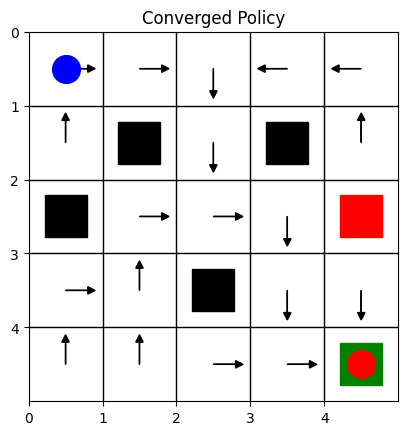

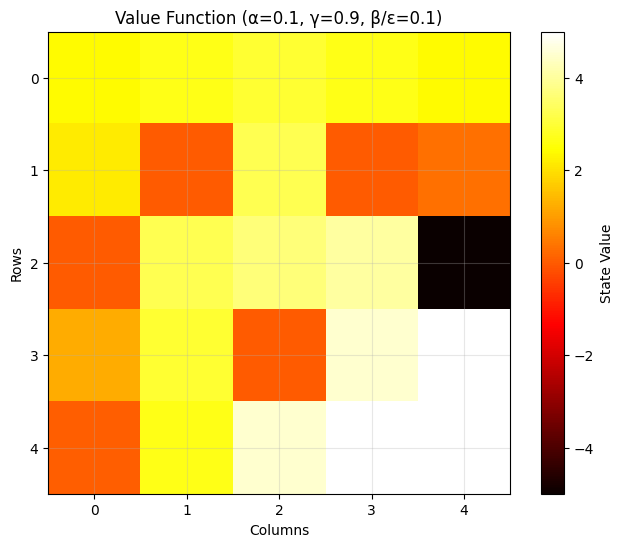

(array([[2, 2, 1, 3, 3],
        [0, 1, 1, 1, 0],
        [0, 2, 2, 1, 2],
        [2, 0, 0, 1, 1],
        [0, 0, 2, 2, 0]]),
 array([[ 2.39184194e+00,  2.65760216e+00,  2.95289129e+00,
          2.65760216e+00,  2.39137148e+00],
        [ 2.15265775e+00,  7.01071173e-04,  3.28099032e+00,
          9.28892828e-04,  3.37265563e-01],
        [ 9.66465666e-04,  3.28099032e+00,  3.64554480e+00,
          4.05060533e+00, -5.00000000e+00],
        [ 1.24698937e+00,  2.95289126e+00,  9.75595533e-04,
          4.50067259e+00,  5.00074733e+00],
        [ 4.63448333e-02,  2.65736671e+00,  4.50067259e+00,
          5.00074733e+00,  5.00000000e+00]]))

In [19]:
grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

env = GridWorld(
                    size=grid_config['size'],
                    start=grid_config['start'],
                    goal_state=grid_config['goal_state'],
                    obstacle_states=grid_config['obstacle_states'],
                    trap_state=grid_config['trap_state'],
                    seed=grid_config['seed']
                )


agent1 = Qlearning(env, alpha=0.1, episodes=100000, seed=27, gamma=0.9, epsilon=0.1)
agent1.train(verbose=True)  # Train the agent first!
agent1.plot_policy_and_value()

In [20]:
agent1.get_training_statistics()

{'total_episodes': 100000,
 'goal_episodes': 97134,
 'trap_episodes': 2865,
 'timeout_episodes': 1,
 'success_rate': 0.97134,
 'trap_rate': 0.02865,
 'timeout_rate': 1e-05,
 'failure_rate': 0.02866,
 'avg_steps': 8.87437,
 'avg_reward': 4.57388,
 'total_steps': 887437,
 'total_reward': 457388}

### Q2 - Do it for A = 0.1, 0.5 and 0.9, take Epsilon = 0.1.

Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.1, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


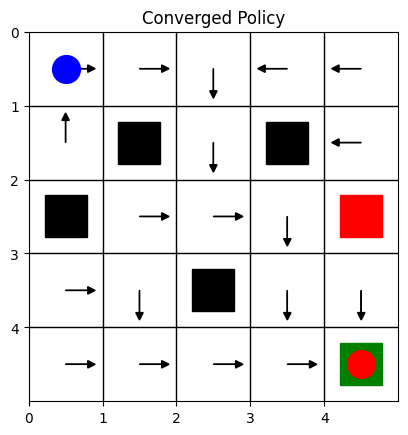

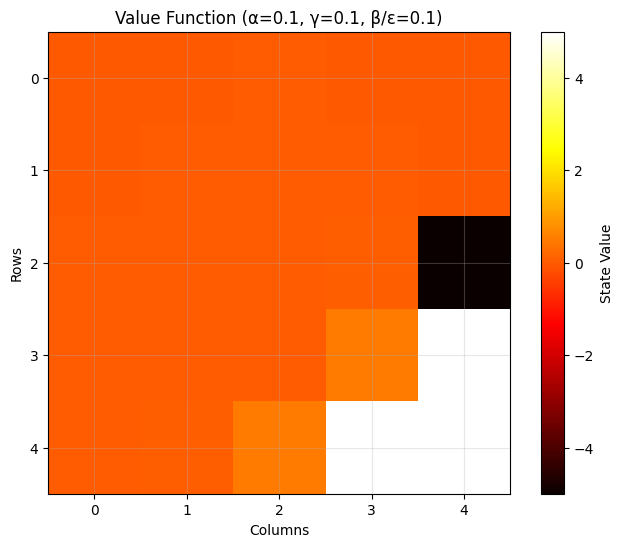

{'total_episodes': 100000, 'goal_episodes': 97124, 'trap_episodes': 2876, 'timeout_episodes': 0, 'success_rate': 0.97124, 'trap_rate': 0.02876, 'timeout_rate': 0.0, 'failure_rate': 0.02876, 'avg_steps': 8.87012, 'avg_reward': 4.57241, 'total_steps': 887012, 'total_reward': 457241}
Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.5, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


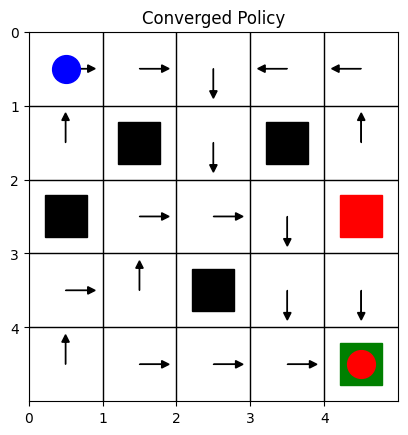

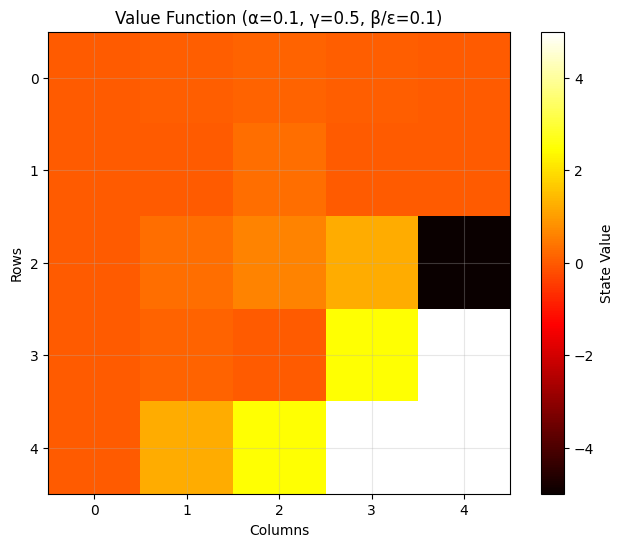

{'total_episodes': 100000, 'goal_episodes': 97132, 'trap_episodes': 2867, 'timeout_episodes': 1, 'success_rate': 0.97132, 'trap_rate': 0.02867, 'timeout_rate': 1e-05, 'failure_rate': 0.02868, 'avg_steps': 8.866, 'avg_reward': 4.57348, 'total_steps': 886600, 'total_reward': 457348}
Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


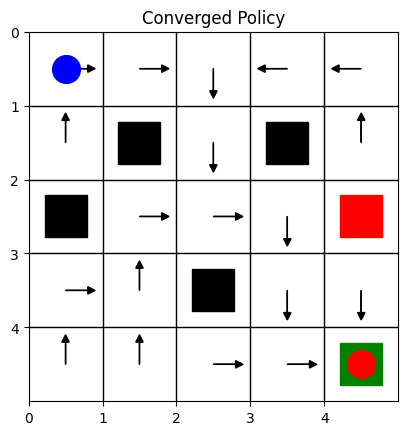

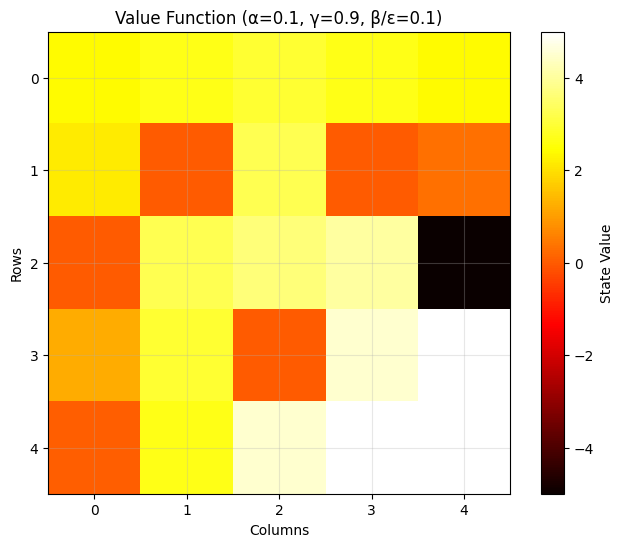

{'total_episodes': 100000, 'goal_episodes': 97134, 'trap_episodes': 2865, 'timeout_episodes': 1, 'success_rate': 0.97134, 'trap_rate': 0.02865, 'timeout_rate': 1e-05, 'failure_rate': 0.02866, 'avg_steps': 8.87437, 'avg_reward': 4.57388, 'total_steps': 887437, 'total_reward': 457388}


In [ ]:
grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

gammas = [0.1, 0.5, 0.9]

for gamma in gammas:

    env = GridWorld(
                        size=grid_config['size'],
                        start=grid_config['start'],
                        goal_state=grid_config['goal_state'],
                        obstacle_states=grid_config['obstacle_states'],
                        trap_state=grid_config['trap_state'],
                        seed=grid_config['seed']
                    )


    agent2 = Qlearning(env, alpha=0.1, episodes=100000, seed=27, gamma=gamma, epsilon=0.1)
    agent2.train(verbose=True)
    agent2.plot_policy_and_value()
    print(agent2.get_training_statistics())

### Q3 - For gamma = 0.9, plot the no. of steps to reach the goal across episodes for epsilon = 0.1, 0.3 and 0.5.

Average Steps / Rewards over Log Episodes

Training with ε = 0.1 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Completed ε = 0.1

Training with ε = 0.3 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Completed ε = 0.3

Training with ε = 0.5 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epo

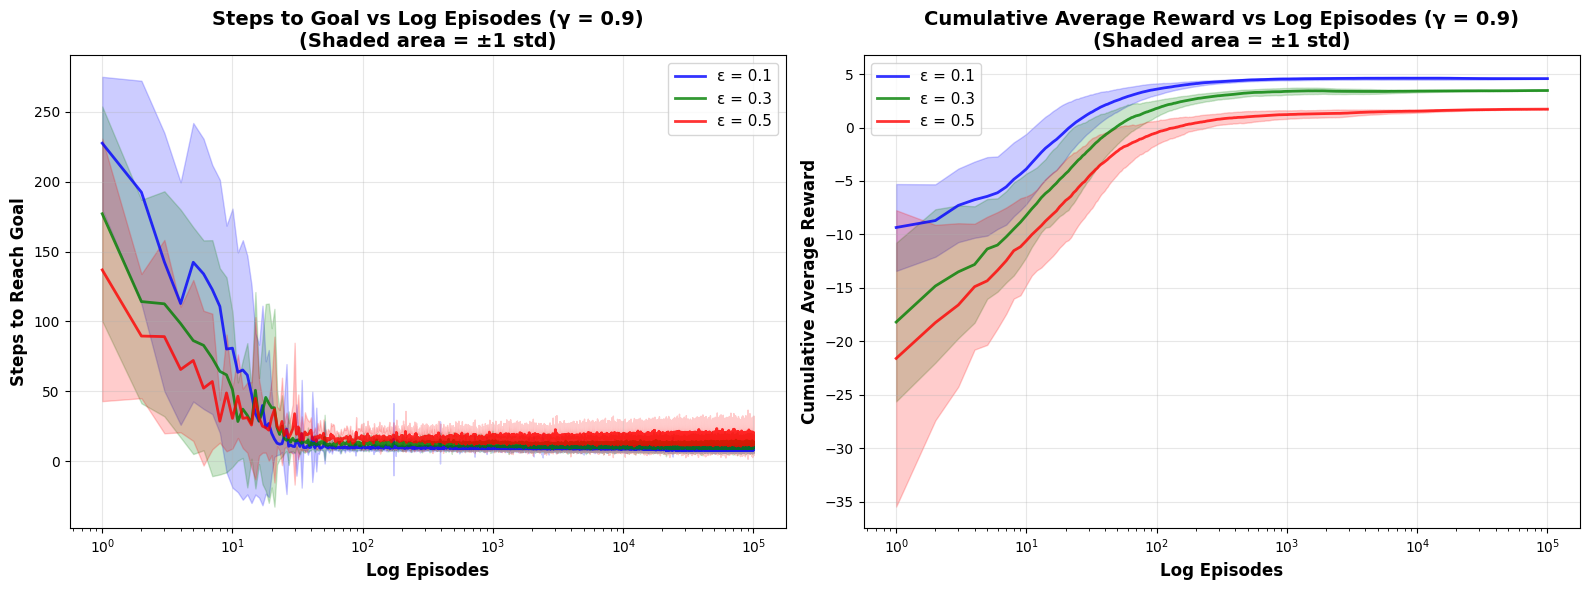

In [29]:
print("=" * 70)
print("Average Steps / Rewards over Log Episodes")
print("=" * 70)

grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

results_3 = Qlearning.run_multiple_epochs(
    env_config=grid_config,
    alpha=0.1,
    episodes=100000,
    gamma=0.9,
    epsilon_values=[0.1, 0.3, 0.5],
    num_epochs=20,
    verbose=True
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED - Generating Plots...")
print("=" * 70)

Qlearning.plot_epsilon_comparison(results_3, gamma=0.9, episodes=100000)


GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE


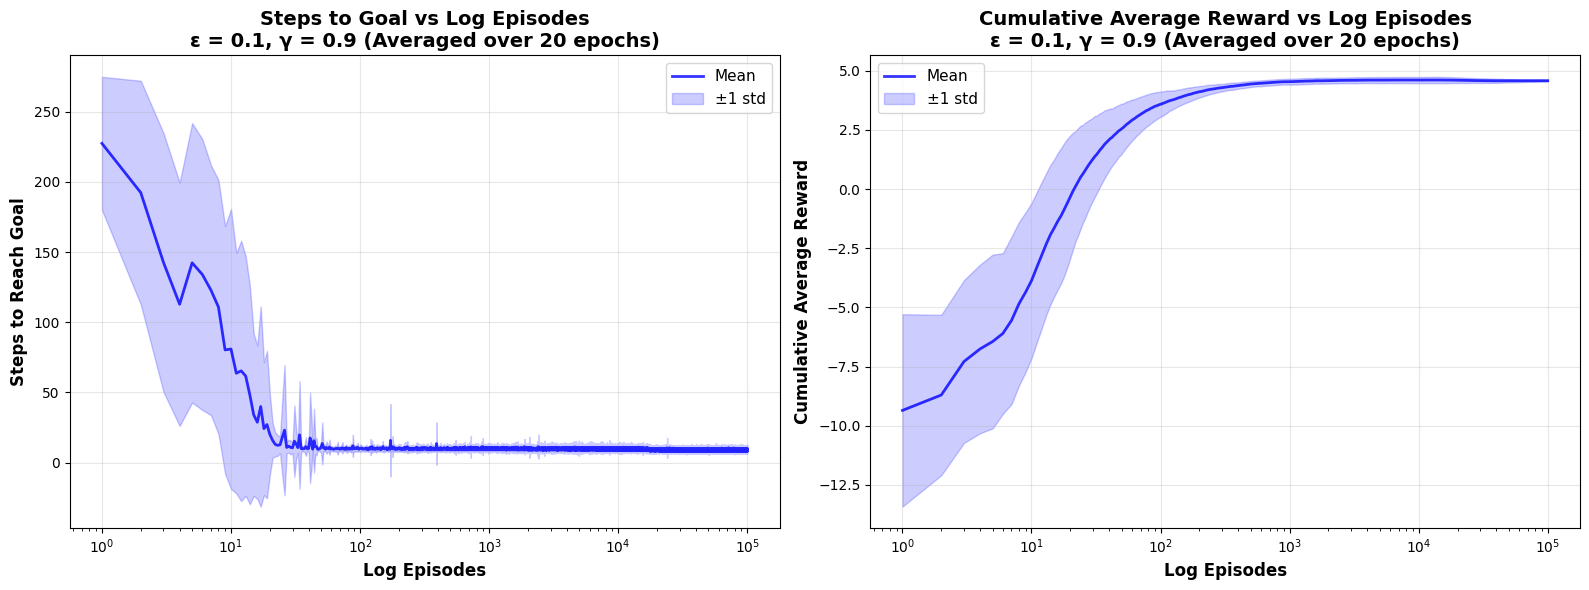


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 8.60 ± 1.36
Final Cumulative Avg Reward:  4.5816 ± 0.0377
Minimum Steps (across all episodes): 7.80
Maximum Cumulative Reward: 4.6121



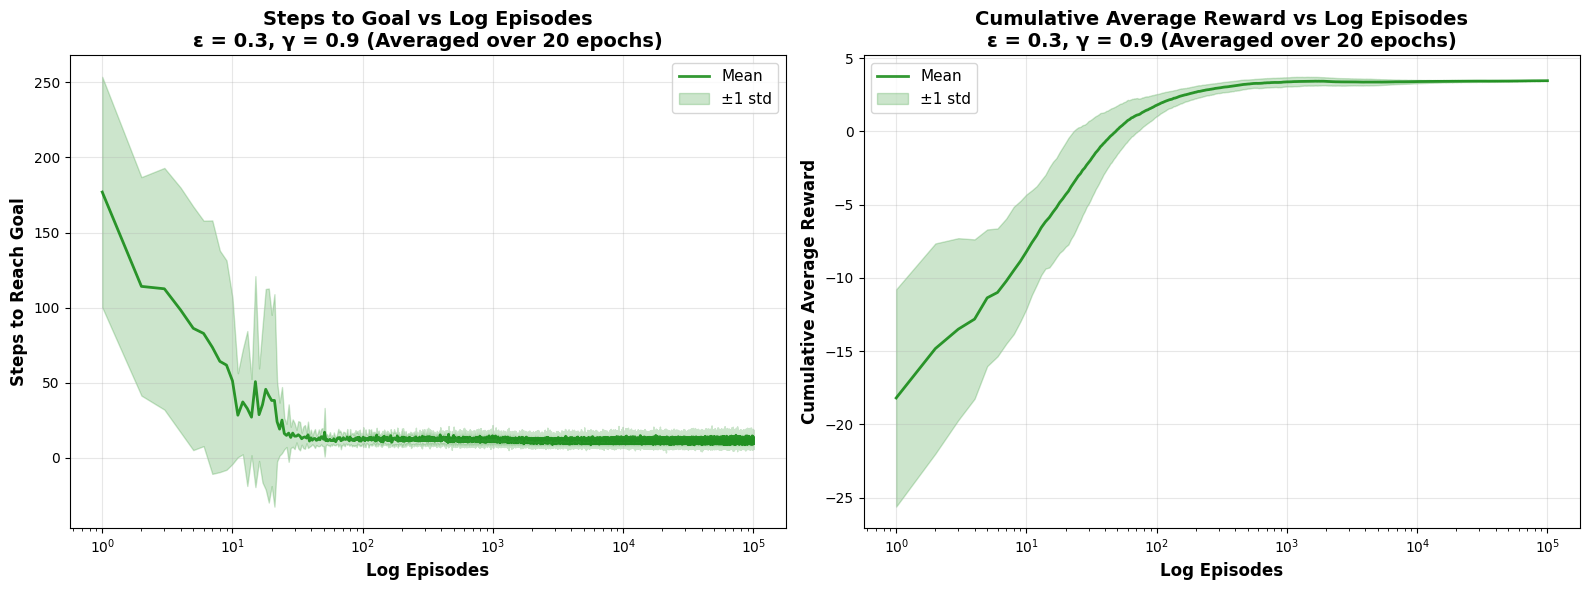


STATISTICS FOR ε = 0.3
Final Average Steps to Goal: 10.10 ± 2.43
Final Cumulative Avg Reward:  3.4691 ± 0.0234
Minimum Steps (across all episodes): 8.70
Maximum Cumulative Reward: 3.4691



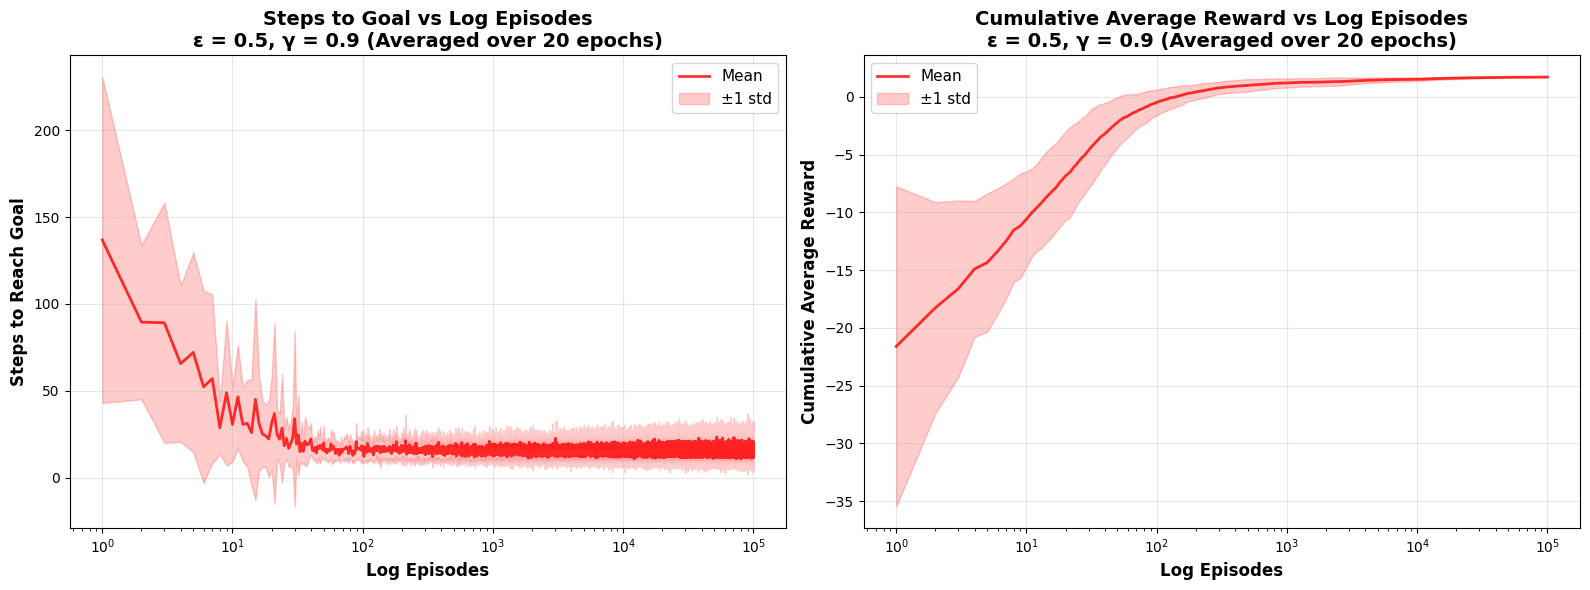


STATISTICS FOR ε = 0.5
Final Average Steps to Goal: 15.65 ± 7.62
Final Cumulative Avg Reward:  1.7194 ± 0.0170
Minimum Steps (across all episodes): 10.80
Maximum Cumulative Reward: 1.7194



In [30]:
print("\n" + "=" * 70)
print("GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE")
print("=" * 70)

Qlearning.plot_epsilon_separate(results_3, gamma=0.9, episodes=100000)

## Part 2

### Q1 - Plot the converged policy and value function for this grid world. Use softmax function for action selection.

Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!
------------------------------------------------------------
Training completed!


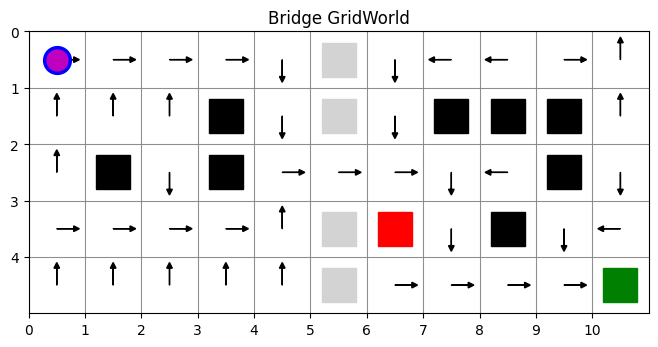

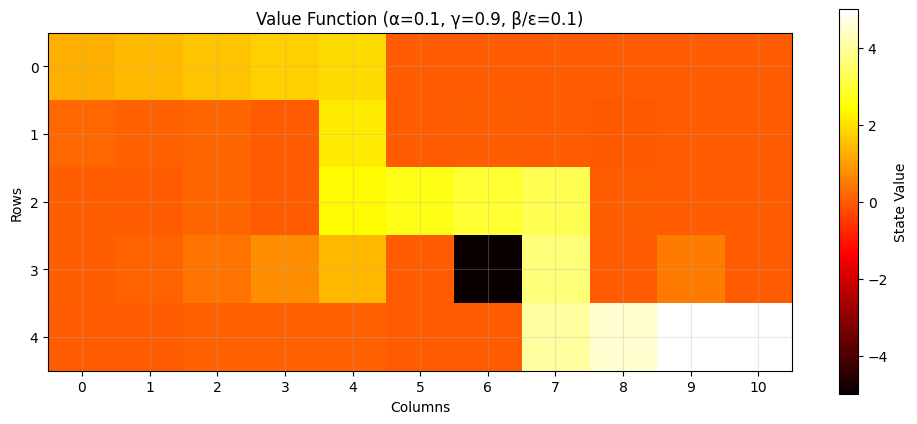

(array([[2, 2, 2, 2, 1, 2, 1, 3, 3, 2, 0],
        [0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 0],
        [0, 1, 1, 0, 2, 2, 2, 1, 3, 2, 1],
        [2, 2, 2, 2, 0, 2, 0, 1, 2, 1, 3],
        [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 3]]),
 array([[ 1.27114031e+00,  1.41237812e+00,  1.56930902e+00,
          1.74367669e+00,  1.93741855e+00,  7.83289802e-04,
          5.86930002e-03,  1.95634573e-03,  8.90705691e-04,
          6.24748206e-04,  8.06528898e-04],
        [ 2.18460523e-01,  9.25119774e-02,  1.66358462e-01,
          9.91710897e-04,  2.15268728e+00,  9.10535370e-04,
          5.50866123e-02,  8.69542857e-04,  3.93213956e-04,
          9.80703014e-04,  6.54530762e-04],
        [ 4.01540545e-02,  9.82805034e-04,  1.71333866e-01,
          9.42747804e-04,  2.39187475e+00,  2.65763861e+00,
          2.95293179e+00,  3.28103532e+00,  5.01537203e-02,
          6.31223626e-04,  9.11699018e-04],
        [ 5.82642966e-02,  1.42576538e-01,  3.77501964e-01,
          7.52163509e-01,  1.37288891e+00,  6.69784

In [28]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=27,
    bridge_state=bridge_state
)

agent_b = Qlearning(env, alpha=0.1, episodes=200000, seed=27, gamma=0.9, epsilon=0.1)
agent_b.train(verbose=True, softmax=True)
agent_b.plot_policy_and_value()

In [29]:
agent_b.get_training_statistics()

{'total_episodes': 200000,
 'goal_episodes': 199984,
 'trap_episodes': 3,
 'timeout_episodes': 13,
 'success_rate': 0.99992,
 'trap_rate': 1.5e-05,
 'timeout_rate': 6.5e-05,
 'failure_rate': 8e-05,
 'avg_steps': np.float64(14.351915),
 'avg_reward': np.float64(4.999525),
 'total_steps': 2870383,
 'total_reward': 999905.0}

Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.3
------------------------------------------------------------
------------------------------------------------------------
Training completed!
------------------------------------------------------------
Training completed!


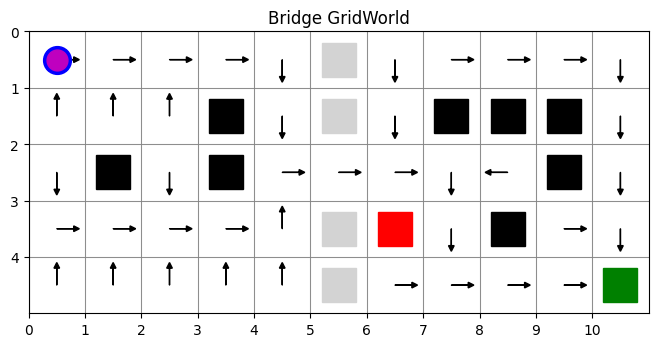

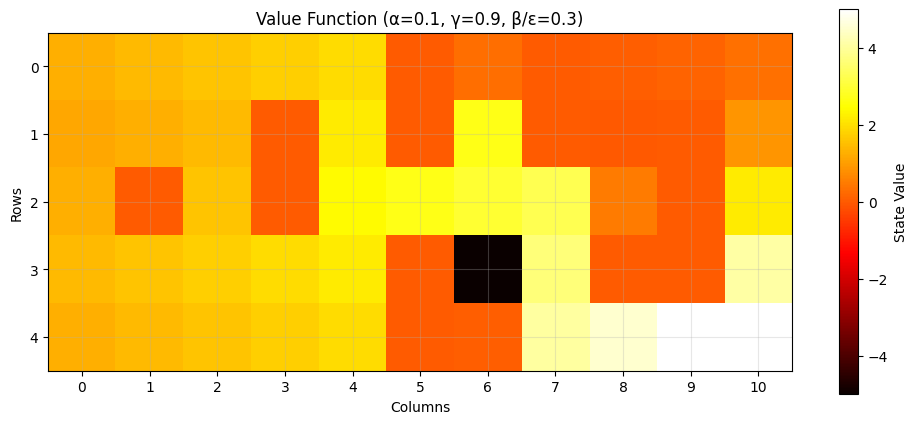

(array([[2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1],
        [0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 2, 2, 2, 1, 3, 2, 1],
        [2, 2, 2, 2, 0, 2, 0, 1, 2, 2, 1],
        [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 3]]),
 array([[ 1.27114031e+00,  1.41237812e+00,  1.56930902e+00,
          1.74367669e+00,  1.93741855e+00,  7.83289802e-04,
          3.11319694e-01,  2.87141732e-02,  5.96311956e-02,
          1.32618241e-01,  3.15999582e-01],
        [ 1.14402628e+00,  1.27114031e+00,  1.41237812e+00,
          9.91710897e-04,  2.15268728e+00,  9.10535370e-04,
          2.65763861e+00,  8.69542857e-04,  3.93213956e-04,
          9.80703014e-04,  8.73213291e-01],
        [ 1.27114031e+00,  9.82805034e-04,  1.56930902e+00,
          9.42747804e-04,  2.39187475e+00,  2.65763861e+00,
          2.95293179e+00,  3.28103532e+00,  4.74612269e-01,
          6.31223626e-04,  2.18424174e+00],
        [ 1.41237812e+00,  1.56930902e+00,  1.74367669e+00,
          1.93741855e+00,  2.15268728e+00,  6.69784

In [57]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=27,
    bridge_state=bridge_state
)

agent_b = Qlearning(env, alpha=0.1, episodes=200000, seed=27, gamma=0.9, epsilon=0.3)
agent_b.train(verbose=True, softmax=True)
agent_b.plot_policy_and_value()

Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.5
------------------------------------------------------------
------------------------------------------------------------
Training completed!
------------------------------------------------------------
Training completed!


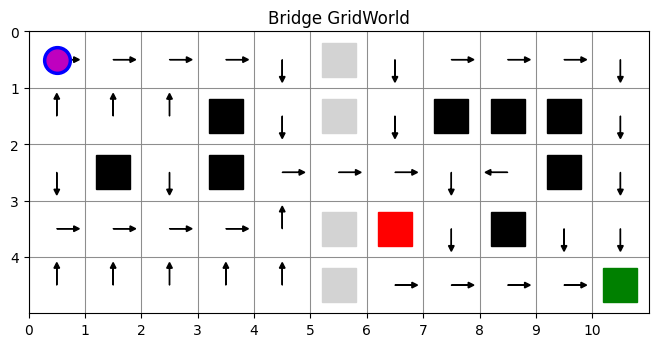

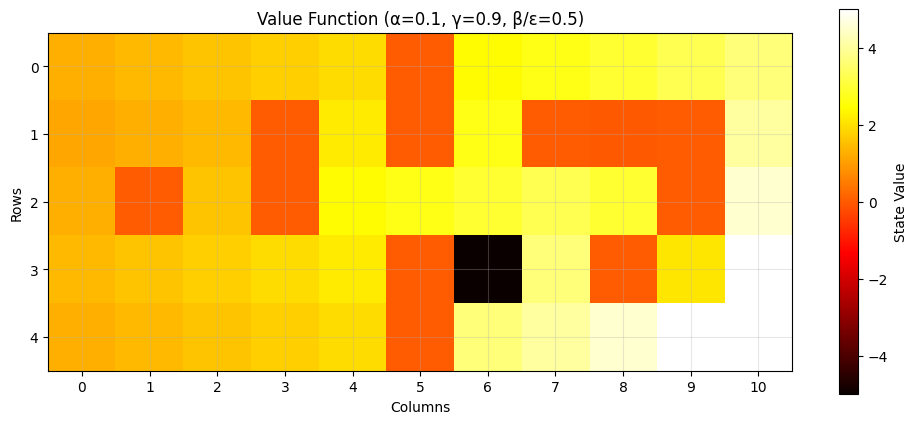

(array([[2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1],
        [0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 2, 2, 2, 1, 3, 2, 1],
        [2, 2, 2, 2, 0, 2, 0, 1, 2, 1, 1],
        [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 3]]),
 array([[ 1.27114031e+00,  1.41237812e+00,  1.56930902e+00,
          1.74367669e+00,  1.93741855e+00,  7.83289802e-04,
          2.39187475e+00,  2.65763861e+00,  2.95293179e+00,
          3.28103532e+00,  3.64559481e+00],
        [ 1.14402628e+00,  1.27114031e+00,  1.41237812e+00,
          9.91710897e-04,  2.15268728e+00,  9.10535370e-04,
          2.65763861e+00,  8.69542857e-04,  3.93213956e-04,
          9.80703014e-04,  4.05066089e+00],
        [ 1.27114031e+00,  9.82805034e-04,  1.56930902e+00,
          9.42747804e-04,  2.39187475e+00,  2.65763861e+00,
          2.95293179e+00,  3.28103532e+00,  2.95293179e+00,
          6.31223626e-04,  4.50073433e+00],
        [ 1.41237812e+00,  1.56930902e+00,  1.74367669e+00,
          1.93741855e+00,  2.15268728e+00,  6.69784

In [58]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=27,
    bridge_state=bridge_state
)

agent_b = Qlearning(env, alpha=0.1, episodes=200000, seed=27, gamma=0.9, epsilon=0.5)
agent_b.train(verbose=True, softmax=True)
agent_b.plot_policy_and_value()

## softmax beta * q values

Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


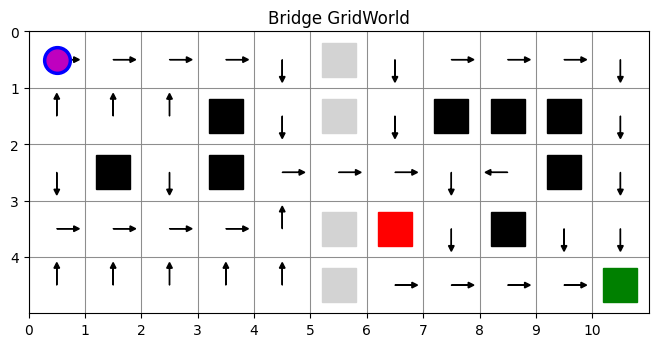

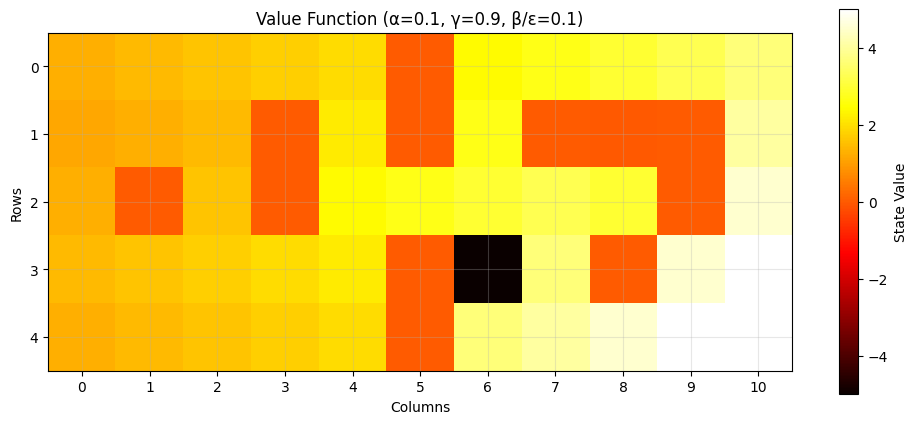

(array([[2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1],
        [0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 2, 2, 2, 1, 3, 2, 1],
        [2, 2, 2, 2, 0, 2, 0, 1, 2, 1, 1],
        [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 3]]),
 array([[ 1.27114031e+00,  1.41237812e+00,  1.56930902e+00,
          1.74367669e+00,  1.93741855e+00,  7.83289802e-04,
          2.39187475e+00,  2.65763861e+00,  2.95293179e+00,
          3.28103532e+00,  3.64559481e+00],
        [ 1.14402628e+00,  1.27114031e+00,  1.41237812e+00,
          9.91710897e-04,  2.15268728e+00,  9.10535370e-04,
          2.65763861e+00,  8.69542857e-04,  3.93213956e-04,
          9.80703014e-04,  4.05066089e+00],
        [ 1.27114031e+00,  9.82805034e-04,  1.56930902e+00,
          9.42747804e-04,  2.39187475e+00,  2.65763861e+00,
          2.95293179e+00,  3.28103532e+00,  2.95293179e+00,
          6.31223626e-04,  4.50073433e+00],
        [ 1.41237812e+00,  1.56930902e+00,  1.74367669e+00,
          1.93741855e+00,  2.15268728e+00,  6.69784

In [6]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=27,
    bridge_state=bridge_state
)

agent_b = Qlearning(env, alpha=0.1, episodes=200000, seed=27, gamma=0.9, epsilon=0.1)
agent_b.train(verbose=True, softmax=True)
agent_b.plot_policy_and_value()

Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.3
------------------------------------------------------------
------------------------------------------------------------
Training completed!


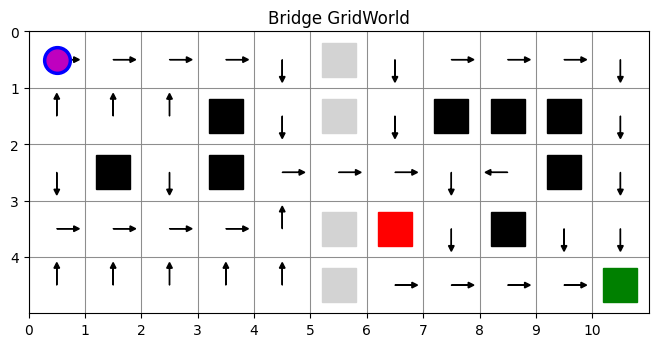

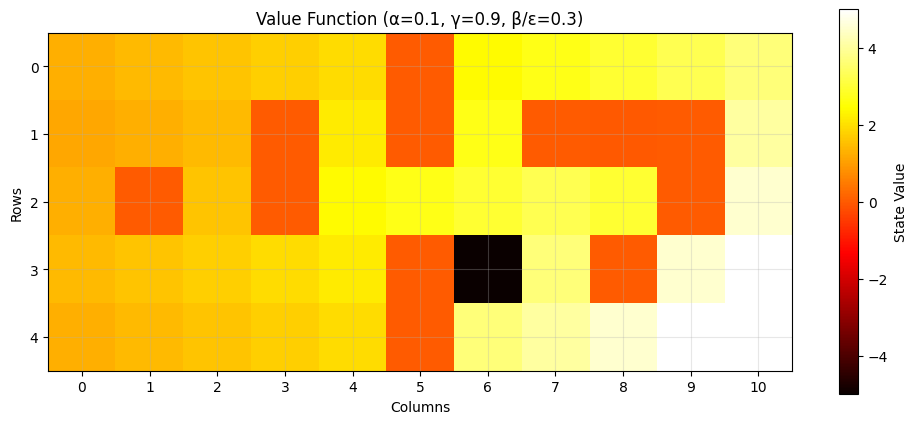

(array([[2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1],
        [0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 2, 2, 2, 1, 3, 2, 1],
        [2, 2, 2, 2, 0, 2, 0, 1, 2, 1, 1],
        [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 3]]),
 array([[ 1.27114031e+00,  1.41237812e+00,  1.56930902e+00,
          1.74367669e+00,  1.93741855e+00,  7.83289802e-04,
          2.39187475e+00,  2.65763861e+00,  2.95293179e+00,
          3.28103532e+00,  3.64559481e+00],
        [ 1.14402628e+00,  1.27114031e+00,  1.41237812e+00,
          9.91710897e-04,  2.15268728e+00,  9.10535370e-04,
          2.65763861e+00,  8.69542857e-04,  3.93213956e-04,
          9.80703014e-04,  4.05066089e+00],
        [ 1.27114031e+00,  9.82805034e-04,  1.56930902e+00,
          9.42747804e-04,  2.39187475e+00,  2.65763861e+00,
          2.95293179e+00,  3.28103532e+00,  2.95293179e+00,
          6.31223626e-04,  4.50073433e+00],
        [ 1.41237812e+00,  1.56930902e+00,  1.74367669e+00,
          1.93741855e+00,  2.15268728e+00,  6.69784

In [7]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=27,
    bridge_state=bridge_state
)

agent_b = Qlearning(env, alpha=0.1, episodes=200000, seed=27, gamma=0.9, epsilon=0.3)
agent_b.train(verbose=True, softmax=True)
agent_b.plot_policy_and_value()

Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.5
------------------------------------------------------------
------------------------------------------------------------
Training completed!


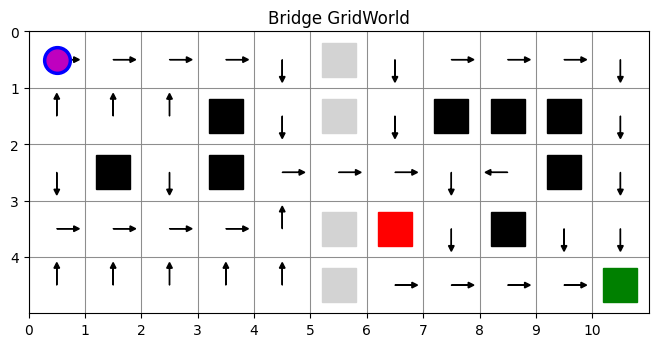

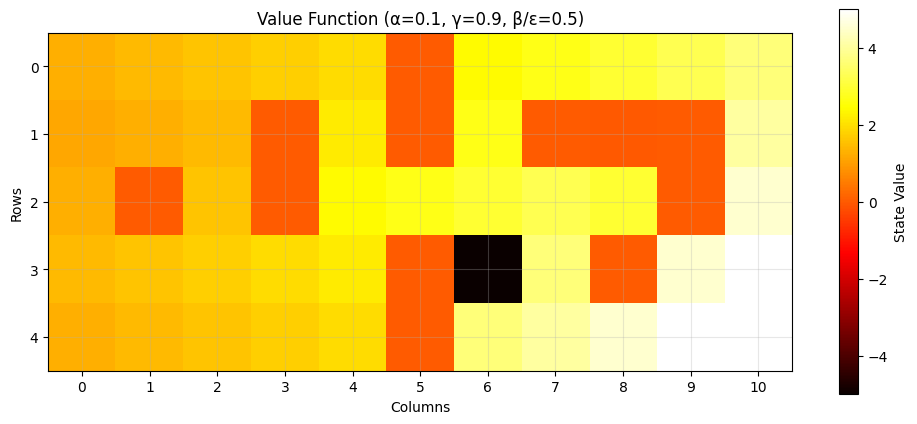

(array([[2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1],
        [0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 2, 2, 2, 1, 3, 2, 1],
        [2, 2, 2, 2, 0, 2, 0, 1, 2, 1, 1],
        [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 3]]),
 array([[ 1.27114031e+00,  1.41237812e+00,  1.56930902e+00,
          1.74367669e+00,  1.93741855e+00,  7.83289802e-04,
          2.39187475e+00,  2.65763861e+00,  2.95293179e+00,
          3.28103532e+00,  3.64559481e+00],
        [ 1.14402628e+00,  1.27114031e+00,  1.41237812e+00,
          9.91710897e-04,  2.15268728e+00,  9.10535370e-04,
          2.65763861e+00,  8.69542857e-04,  3.93213956e-04,
          9.80703014e-04,  4.05066089e+00],
        [ 1.27114031e+00,  9.82805034e-04,  1.56930902e+00,
          9.42747804e-04,  2.39187475e+00,  2.65763861e+00,
          2.95293179e+00,  3.28103532e+00,  2.95293179e+00,
          6.31223626e-04,  4.50073433e+00],
        [ 1.41237812e+00,  1.56930902e+00,  1.74367669e+00,
          1.93741855e+00,  2.15268728e+00,  6.69784

In [8]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=27,
    bridge_state=bridge_state
)

agent_b = Qlearning(env, alpha=0.1, episodes=200000, seed=27, gamma=0.9, epsilon=0.5)
agent_b.train(verbose=True, softmax=True)
agent_b.plot_policy_and_value()

### Q2 - Do it for A = 0.1, 0.5 and 0.9, take beta = 0.1.

Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.1, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!
------------------------------------------------------------
Training completed!


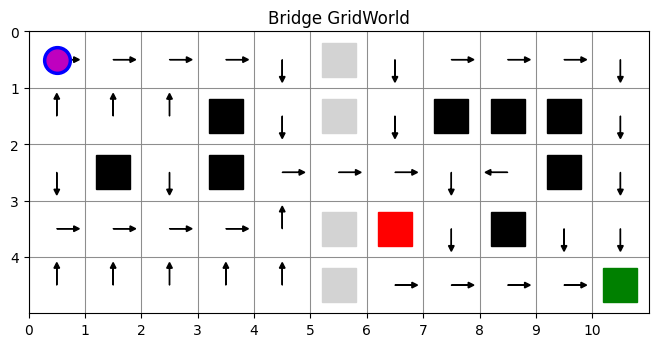

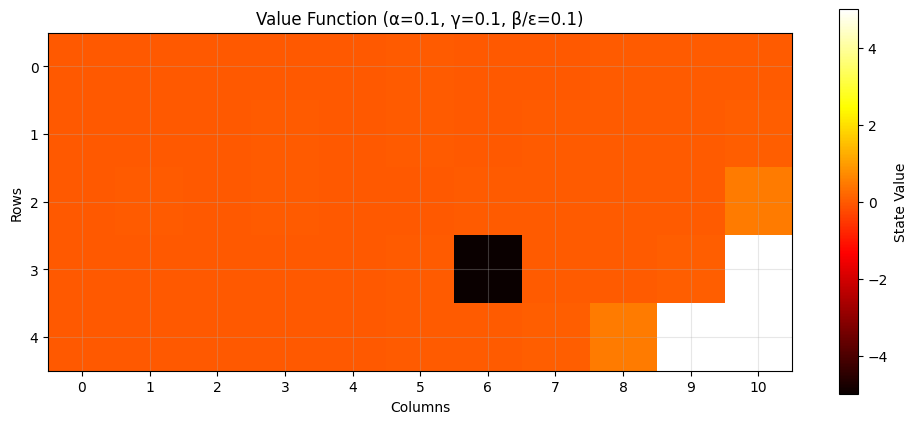

{'total_episodes': 200000, 'goal_episodes': 121575, 'trap_episodes': 10, 'timeout_episodes': 78415, 'success_rate': 0.607875, 'trap_rate': 5e-05, 'timeout_rate': 0.392075, 'failure_rate': 0.392125, 'avg_steps': np.float64(382.019145), 'avg_reward': np.float64(3.039125), 'total_steps': 76403829, 'total_reward': 607825.0}
Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.5, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!
------------------------------------------------------------
Training completed!


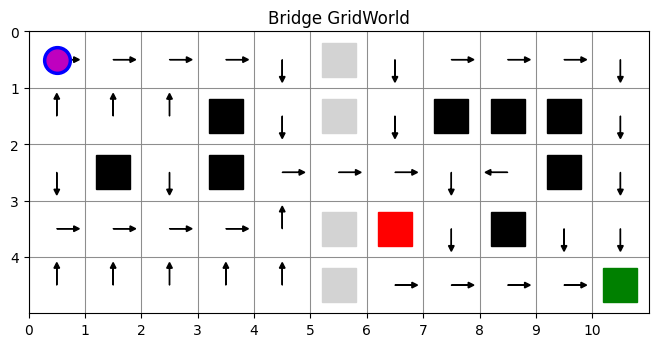

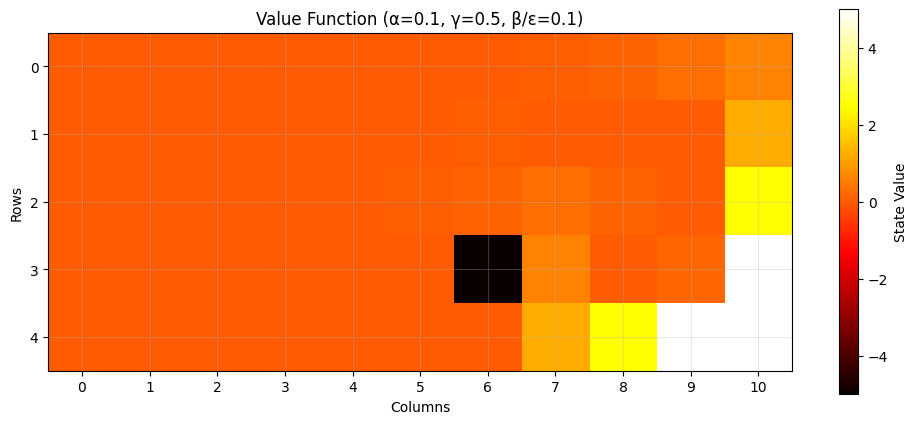

{'total_episodes': 200000, 'goal_episodes': 189178, 'trap_episodes': 6, 'timeout_episodes': 10816, 'success_rate': 0.94589, 'trap_rate': 3e-05, 'timeout_rate': 0.05408, 'failure_rate': 0.05411, 'avg_steps': np.float64(201.817365), 'avg_reward': np.float64(4.7293), 'total_steps': 40363473, 'total_reward': 945860.0}
Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!
------------------------------------------------------------
Training completed!


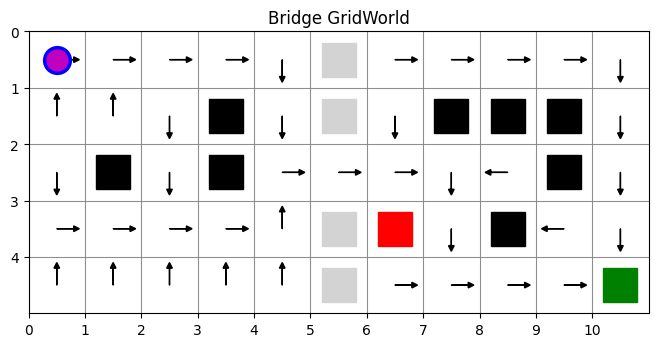

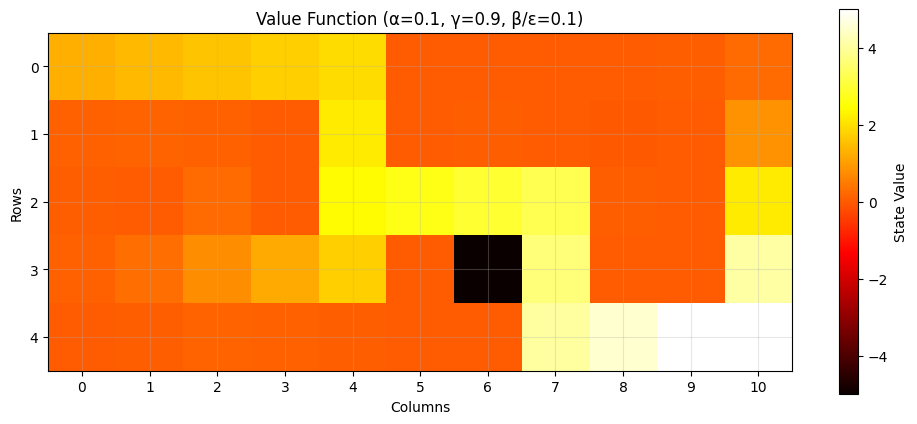

{'total_episodes': 200000, 'goal_episodes': 199980, 'trap_episodes': 3, 'timeout_episodes': 17, 'success_rate': 0.9999, 'trap_rate': 1.5e-05, 'timeout_rate': 8.5e-05, 'failure_rate': 0.0001, 'avg_steps': np.float64(14.52602), 'avg_reward': np.float64(4.999425), 'total_steps': 2905204, 'total_reward': 999885.0}


In [30]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

gammas = [0.1, 0.5, 0.9]

for gamma in gammas:
    gamma_3_env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=27,
    bridge_state=bridge_state
    )

    bridgeAgent2_9 = Qlearning(gamma_3_env, alpha=0.1, episodes=200000, seed=27, gamma=gamma, epsilon=0.1)
    bridgeAgent2_9.train(verbose=True, softmax=True)
    bridgeAgent2_9.plot_policy_and_value()
    print(bridgeAgent2_9.get_training_statistics())

## Softmax - b * q Q2

Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.1, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


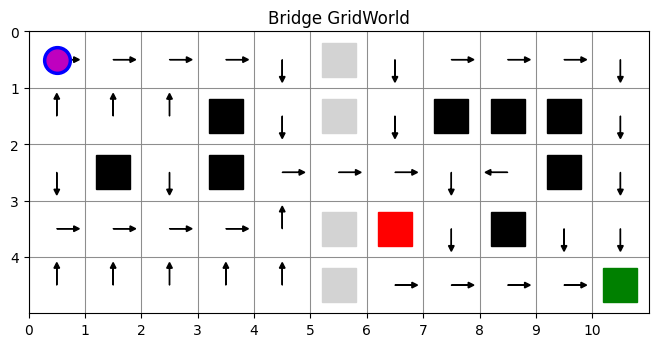

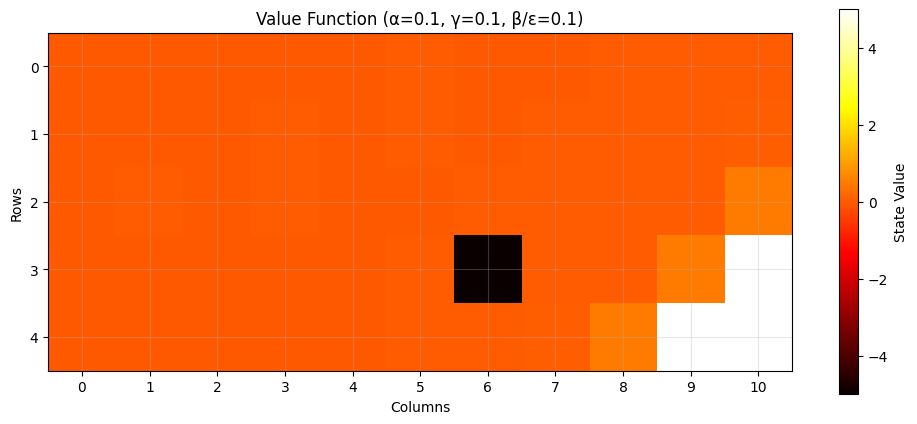

{'total_episodes': 200000, 'goal_episodes': 24953, 'trap_episodes': 126467, 'timeout_episodes': 48580, 'success_rate': 0.124765, 'trap_rate': 0.632335, 'timeout_rate': 0.2429, 'failure_rate': 0.875235, 'avg_steps': np.float64(316.74065), 'avg_reward': np.float64(-102.89458), 'total_steps': 63348130, 'total_reward': -20578916.0}
Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.5, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


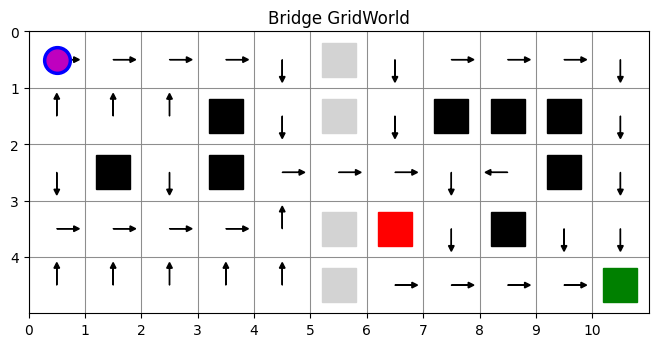

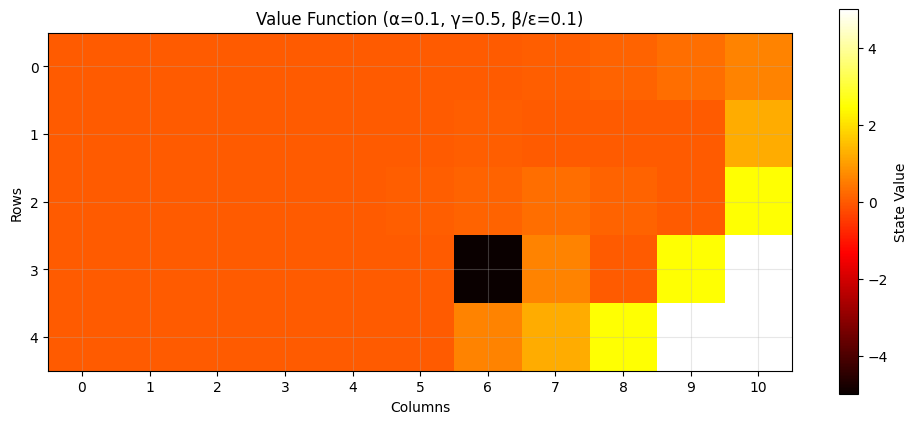

{'total_episodes': 200000, 'goal_episodes': 27374, 'trap_episodes': 124690, 'timeout_episodes': 47936, 'success_rate': 0.13687, 'trap_rate': 0.62345, 'timeout_rate': 0.23968, 'failure_rate': 0.86313, 'avg_steps': np.float64(314.895605), 'avg_reward': np.float64(-102.159015), 'total_steps': 62979121, 'total_reward': -20431803.0}
Starting Q-learning training (Numba-optimized)...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


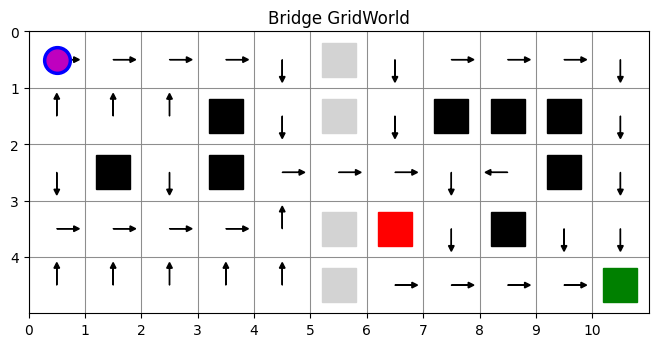

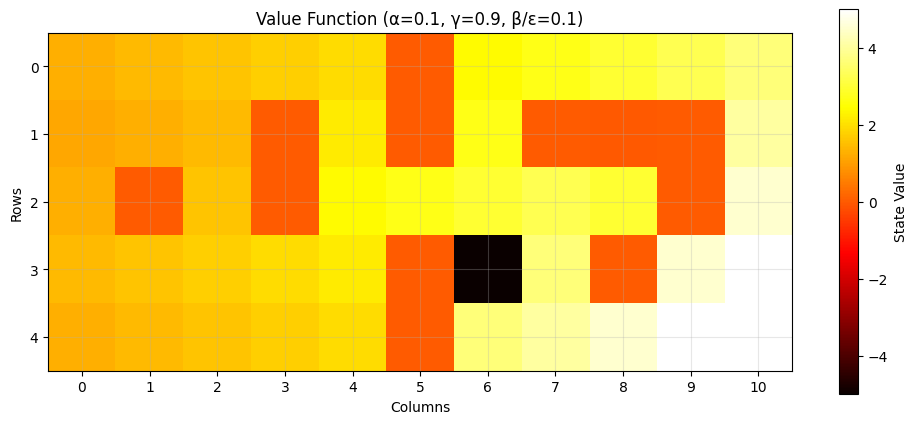

{'total_episodes': 200000, 'goal_episodes': 35375, 'trap_episodes': 124687, 'timeout_episodes': 39938, 'success_rate': 0.176875, 'trap_rate': 0.623435, 'timeout_rate': 0.19969, 'failure_rate': 0.823125, 'avg_steps': np.float64(299.479395), 'avg_reward': np.float64(-97.658485), 'total_steps': 59895879, 'total_reward': -19531697.0}


In [19]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

gammas = [0.1, 0.5, 0.9]

for gamma in gammas:
    gamma_3_env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=27,
    bridge_state=bridge_state
    )

    bridgeAgent2_9 = Qlearning(gamma_3_env, alpha=0.1, episodes=200000, seed=27, gamma=gamma, epsilon=0.1)
    bridgeAgent2_9.train(verbose=True, softmax=True)
    bridgeAgent2_9.plot_policy_and_value()
    print(bridgeAgent2_9.get_training_statistics())

### Q3 - For gamma = 0.9, plot the no. of steps to reach the goal across episodes for beta/epsilon = 0.1, 0.3 and 0.5.

In [ ]:
NUM_EPOCHS_BRIDGE = 20          # Number of epochs to average over
NUM_EPISODES_BRIDGE = 200000    # Episodes per epoch (200K for convergence)
ALPHA_BRIDGE = 0.1              # Learning rate
GAMMA_BRIDGE = 0.9              # Discount factor
EPSILON_VALUES_BRIDGE = [0.1, 0.3, 0.5]  # Beta/temperature values for softmax

# Environment configuration
BRIDGE_CONFIG = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}


BRIDGEGRIDWORLD - TRAINING ALL BETA VALUES (COMBINED)
Training with β = [0.1, 0.3, 0.5]
Epochs: 20, Episodes: 200,000

Training BridgeGridWorld with β = 0.1 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Epoch 20/20... Done
Done
Completed β = 0.1

Training BridgeGridWorld with β = 0.3 (γ = 0.9

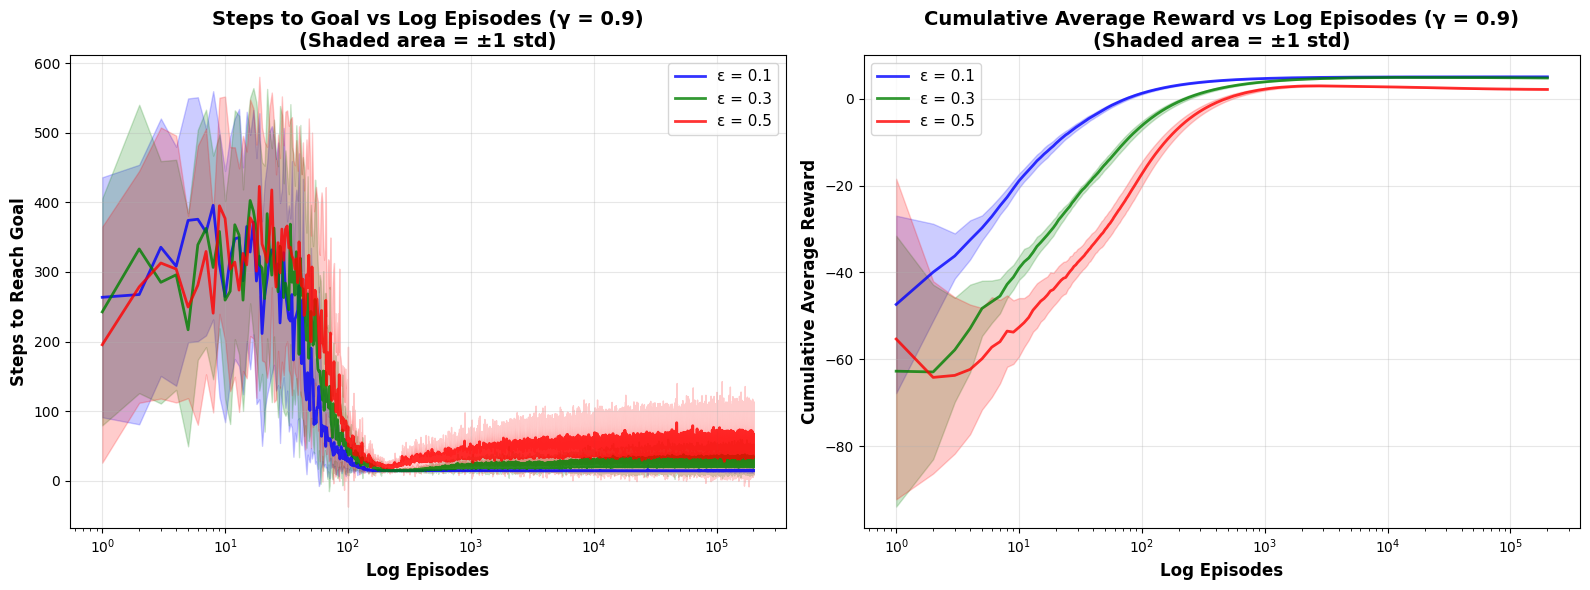

In [62]:
import time

print("=" * 70)
print("BRIDGEGRIDWORLD - TRAINING ALL BETA VALUES (COMBINED)")
print("=" * 70)
print(f"Training with β = {EPSILON_VALUES_BRIDGE}")
print(f"Epochs: {NUM_EPOCHS_BRIDGE}, Episodes: {NUM_EPISODES_BRIDGE:,}")
print("=" * 70)

start_time_all = time.time()

results_bridge_q3 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=BRIDGE_CONFIG,
    alpha=ALPHA_BRIDGE,
    episodes=NUM_EPISODES_BRIDGE,
    gamma=GAMMA_BRIDGE,
    epsilon_values=EPSILON_VALUES_BRIDGE,
    num_epochs=NUM_EPOCHS_BRIDGE,
    verbose=True
)

elapsed_time_all = time.time() - start_time_all

print("\n" + "=" * 70)
print(f"✓ ALL BETA VALUES COMPLETED!")
print(f"  Total time: {elapsed_time_all:.2f}s ({elapsed_time_all/60:.2f} min)")
print(f"  Average time per beta: {elapsed_time_all/len(EPSILON_VALUES_BRIDGE):.2f}s")
print("=" * 70)

# Generate combined comparison plot
Qlearning.plot_epsilon_comparison(results_bridge_q3, gamma=GAMMA_BRIDGE, episodes=NUM_EPISODES_BRIDGE)

### Training: β = 0.1 (Lower Temperature - More Greedy)

BRIDGEGRIDWORLD - TRAINING β = 0.1
Epochs: 20, Episodes: 200,000

Training BridgeGridWorld with β = 0.1 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Epoch 20/20... Done
Done
Completed β = 0.1

✓ β = 0.1 COMPLETED in 121.74s (2.03 min)
Completed β = 0.1

✓ β = 0.1 COMPLETED in 121.74s (2.03 m

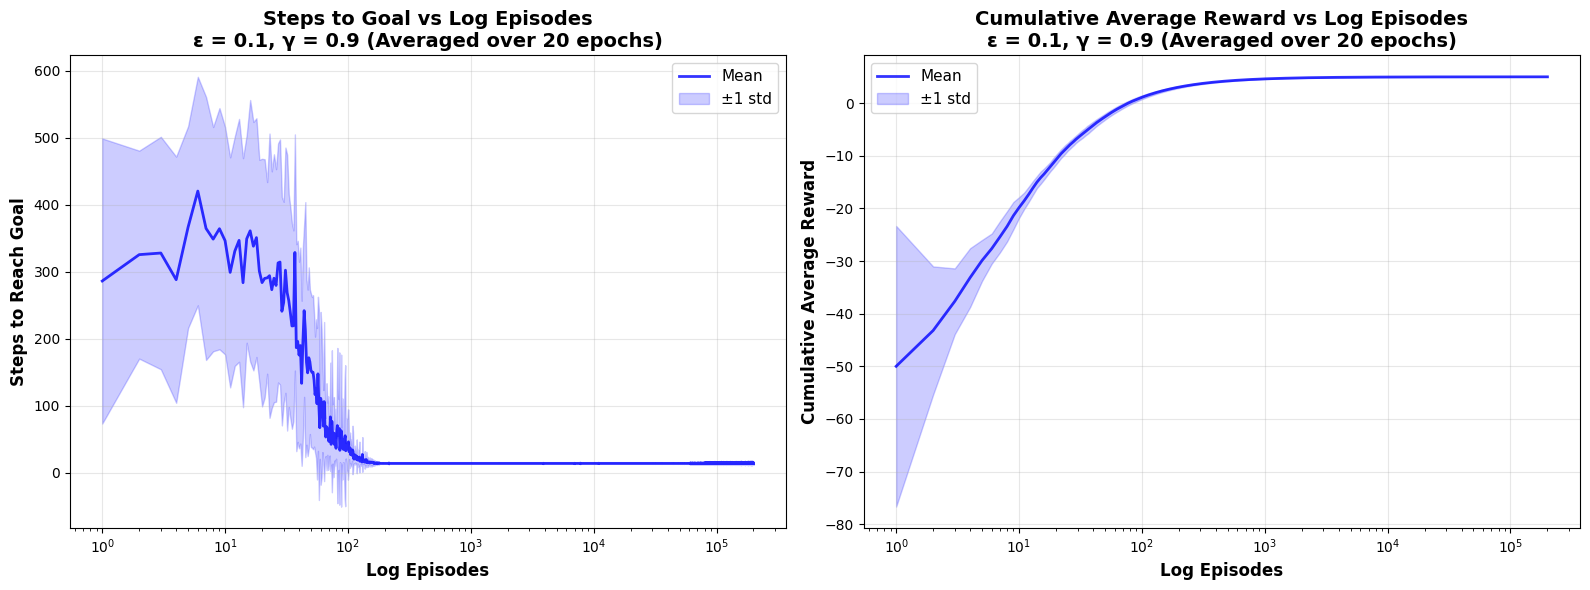


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 14.20 ± 0.60
Final Cumulative Avg Reward:  4.9980 ± 0.0002
Minimum Steps (across all episodes): 14.20
Maximum Cumulative Reward: 4.9980



In [61]:
import time

print("=" * 70)
print("BRIDGEGRIDWORLD - TRAINING β = 0.1")
print("=" * 70)
print(f"Epochs: {NUM_EPOCHS_BRIDGE}, Episodes: {NUM_EPISODES_BRIDGE:,}")
print("=" * 70)

start_time = time.time()

results_bridge_beta_01 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=BRIDGE_CONFIG,
    alpha=ALPHA_BRIDGE,
    episodes=NUM_EPISODES_BRIDGE,
    gamma=GAMMA_BRIDGE,
    epsilon_values=[0.1],
    num_epochs=NUM_EPOCHS_BRIDGE,
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print(f"✓ β = 0.1 COMPLETED in {elapsed_time:.2f}s ({elapsed_time/60:.2f} min)")
print("=" * 70)

# Plot individual results
Qlearning.plot_epsilon_separate(results_bridge_beta_01, gamma=GAMMA_BRIDGE, episodes=NUM_EPISODES_BRIDGE)

### Training: β = 0.3 (Medium Temperature - Balanced)

BRIDGEGRIDWORLD - TRAINING β = 0.3
Epochs: 20, Episodes: 200,000

Training BridgeGridWorld with β = 0.3 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Epoch 20/20... Done
Done
Completed β = 0.3

✓ β = 0.3 COMPLETED in 195.32s (3.26 min)
Completed β = 0.3

✓ β = 0.3 COMPLETED in 195.32s (3.26 m

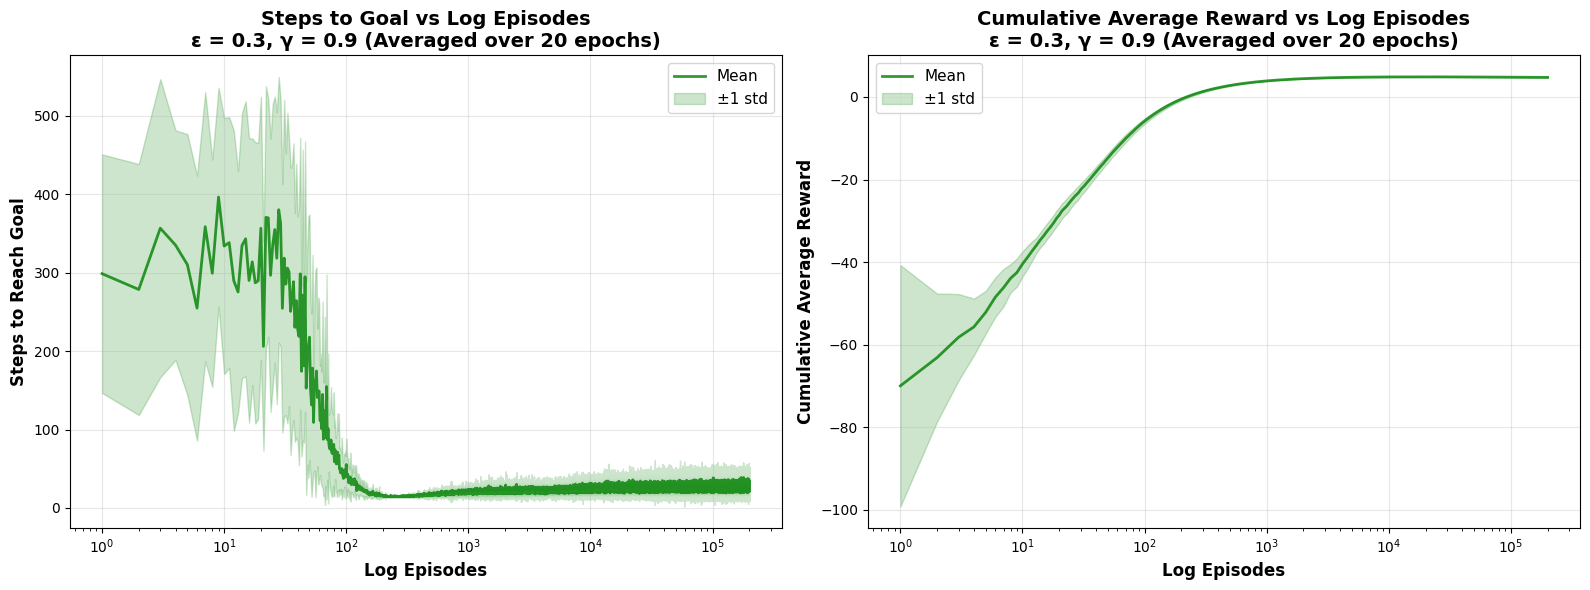


STATISTICS FOR ε = 0.3
Final Average Steps to Goal: 27.50 ± 13.10
Final Cumulative Avg Reward:  4.7421 ± 0.0086
Minimum Steps (across all episodes): 14.30
Maximum Cumulative Reward: 4.8705



In [60]:
import time

print("=" * 70)
print("BRIDGEGRIDWORLD - TRAINING β = 0.3")
print("=" * 70)
print(f"Epochs: {NUM_EPOCHS_BRIDGE}, Episodes: {NUM_EPISODES_BRIDGE:,}")
print("=" * 70)

start_time = time.time()

results_bridge_beta_03 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=BRIDGE_CONFIG,
    alpha=ALPHA_BRIDGE,
    episodes=NUM_EPISODES_BRIDGE,
    gamma=GAMMA_BRIDGE,
    epsilon_values=[0.3],
    num_epochs=NUM_EPOCHS_BRIDGE,
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print(f"✓ β = 0.3 COMPLETED in {elapsed_time:.2f}s ({elapsed_time/60:.2f} min)")
print("=" * 70)

# Plot individual results
Qlearning.plot_epsilon_separate(results_bridge_beta_03, gamma=GAMMA_BRIDGE, episodes=NUM_EPISODES_BRIDGE)

### Training: β = 0.5 (Higher Temperature - More Exploration)

BRIDGEGRIDWORLD - TRAINING β = 0.5
Epochs: 20, Episodes: 200,000

Training BridgeGridWorld with β = 0.5 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Epoch 20/20... Done
Done
Completed β = 0.5

✓ β = 0.5 COMPLETED in 323.24s (5.39 min)
Completed β = 0.5

✓ β = 0.5 COMPLETED in 323.24s (5.39 m

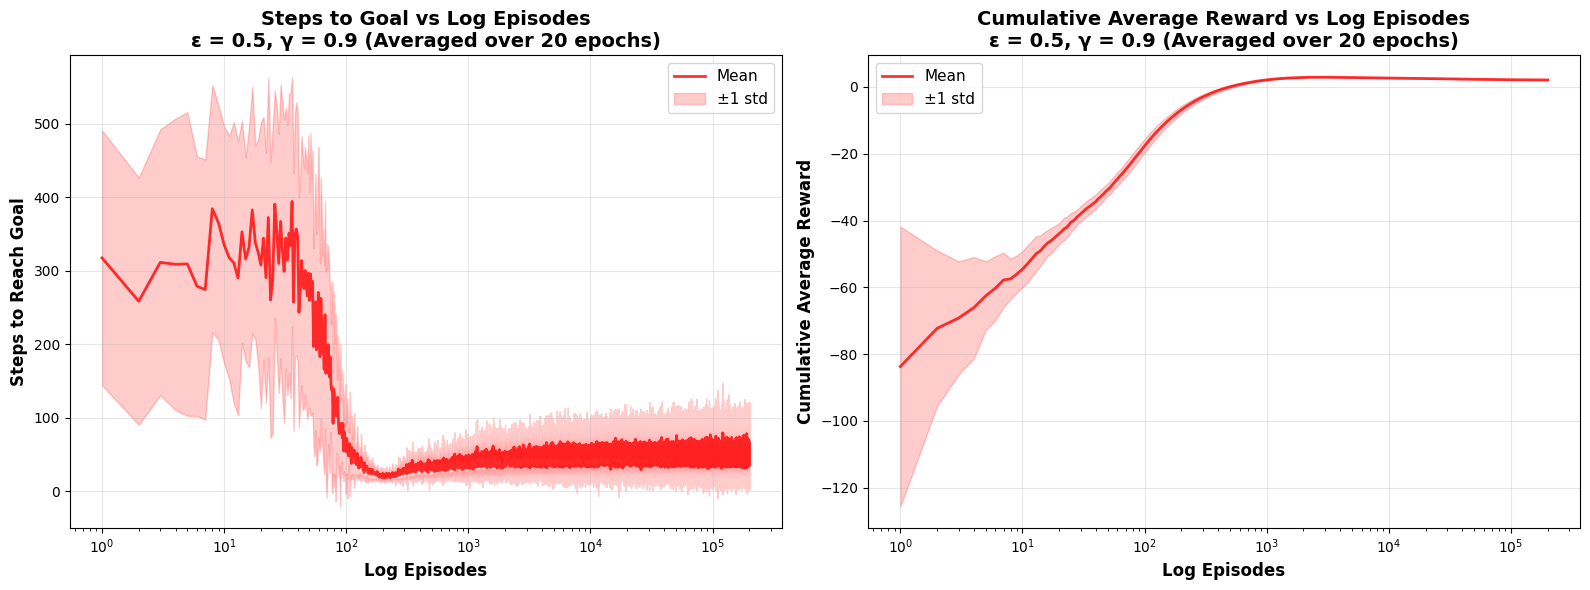


STATISTICS FOR ε = 0.5
Final Average Steps to Goal: 51.95 ± 20.06
Final Cumulative Avg Reward:  2.0998 ± 0.0203
Minimum Steps (across all episodes): 18.15
Maximum Cumulative Reward: 2.9333



In [56]:
import time

print("=" * 70)
print("BRIDGEGRIDWORLD - TRAINING β = 0.5")
print("=" * 70)
print(f"Epochs: {NUM_EPOCHS_BRIDGE}, Episodes: {NUM_EPISODES_BRIDGE:,}")
print("=" * 70)

start_time = time.time()

results_bridge_beta_05 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=BRIDGE_CONFIG,
    alpha=ALPHA_BRIDGE,
    episodes=NUM_EPISODES_BRIDGE,
    gamma=GAMMA_BRIDGE,
    epsilon_values=[0.5],
    num_epochs=NUM_EPOCHS_BRIDGE,
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print(f"✓ β = 0.5 COMPLETED in {elapsed_time:.2f}s ({elapsed_time/60:.2f} min)")
print("=" * 70)

# Plot individual results
Qlearning.plot_epsilon_separate(results_bridge_beta_05, gamma=GAMMA_BRIDGE, episodes=NUM_EPISODES_BRIDGE)

## Softmax -  b * q Q3

In [20]:
NUM_EPOCHS_BRIDGE = 20          # Number of epochs to average over
NUM_EPISODES_BRIDGE = 200000    # Episodes per epoch (200K for convergence)
ALPHA_BRIDGE = 0.1              # Learning rate
GAMMA_BRIDGE = 0.9              # Discount factor
EPSILON_VALUES_BRIDGE = [0.1, 0.3, 0.5]  # Beta/temperature values for softmax

# Environment configuration
BRIDGE_CONFIG = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

Training with β = [0.1, 0.3, 0.5]
Epochs: 20, Episodes: 200,000

Training BridgeGridWorld with β = 0.1 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Completed β = 0.1

Training BridgeGridWorld with β = 0.3 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Completed β = 0.3

Training BridgeGrid

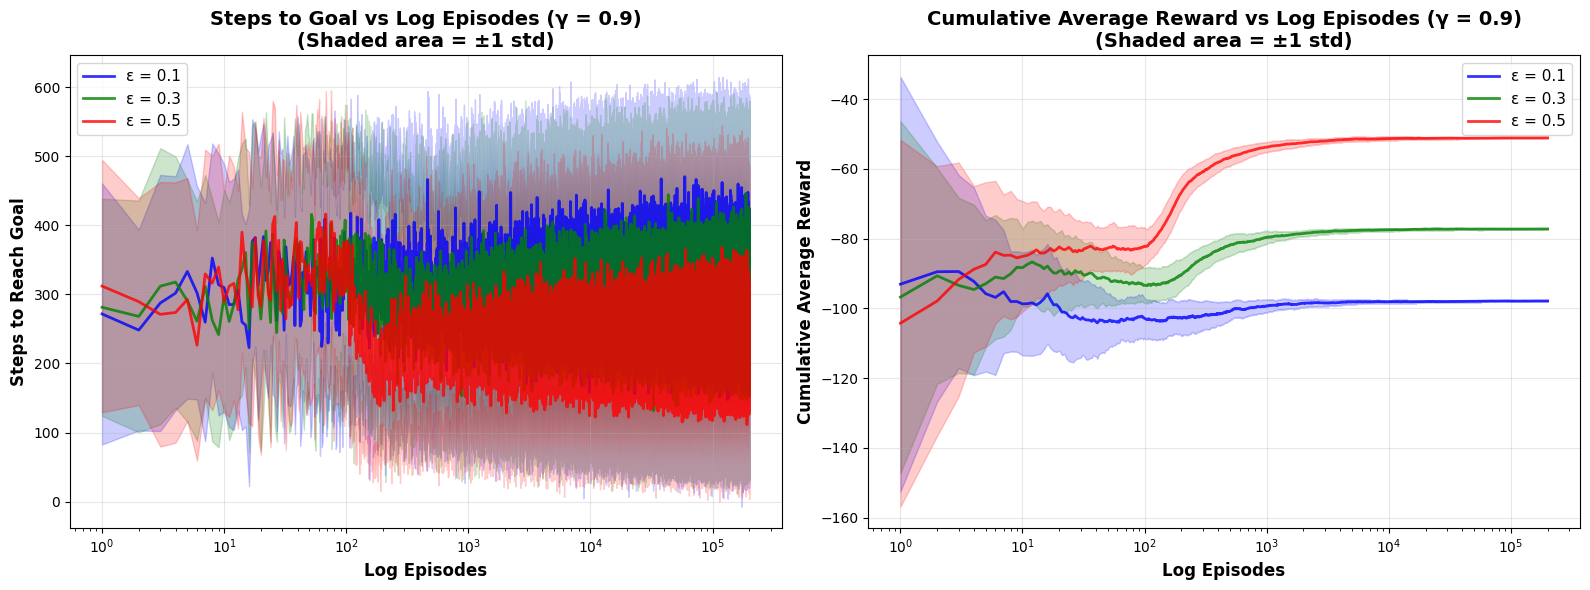

In [21]:
import time

print(f"Training with β = {EPSILON_VALUES_BRIDGE}")
print(f"Epochs: {NUM_EPOCHS_BRIDGE}, Episodes: {NUM_EPISODES_BRIDGE:,}")
print("=" * 70)

start_time_all = time.time()

results_bridge_q3_2 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=BRIDGE_CONFIG,
    alpha=ALPHA_BRIDGE,
    episodes=NUM_EPISODES_BRIDGE,
    gamma=GAMMA_BRIDGE,
    epsilon_values=EPSILON_VALUES_BRIDGE,
    num_epochs=NUM_EPOCHS_BRIDGE,
    verbose=True
)

# Generate combined comparison plot
Qlearning.plot_epsilon_comparison(results_bridge_q3_2, gamma=GAMMA_BRIDGE, episodes=NUM_EPISODES_BRIDGE)

### Separate epsilon plot for 20 Epochs with softmax beta * q values

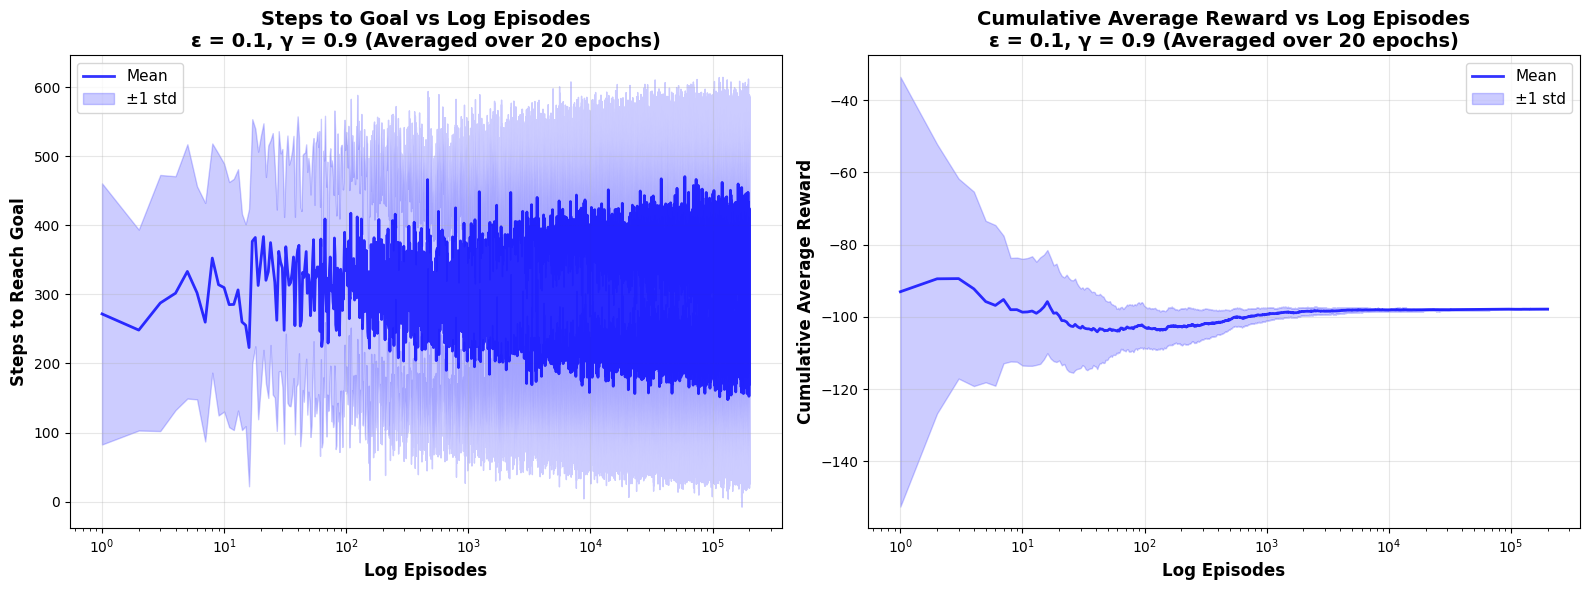


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 321.00 ± 173.89
Final Cumulative Avg Reward:  -97.8520 ± 0.1032
Minimum Steps (across all episodes): 148.05
Maximum Cumulative Reward: -89.4167



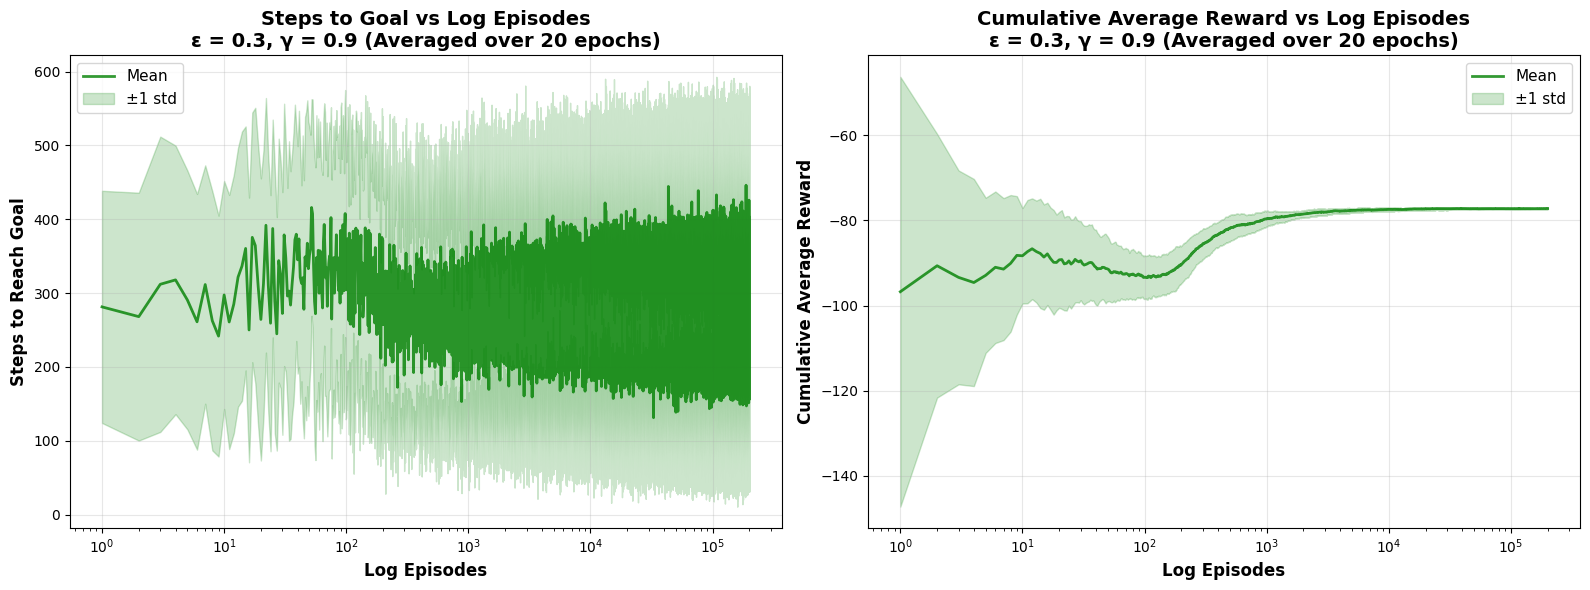


STATISTICS FOR ε = 0.3
Final Average Steps to Goal: 310.10 ± 157.78
Final Cumulative Avg Reward:  -77.2090 ± 0.0823
Minimum Steps (across all episodes): 131.35
Maximum Cumulative Reward: -77.2022



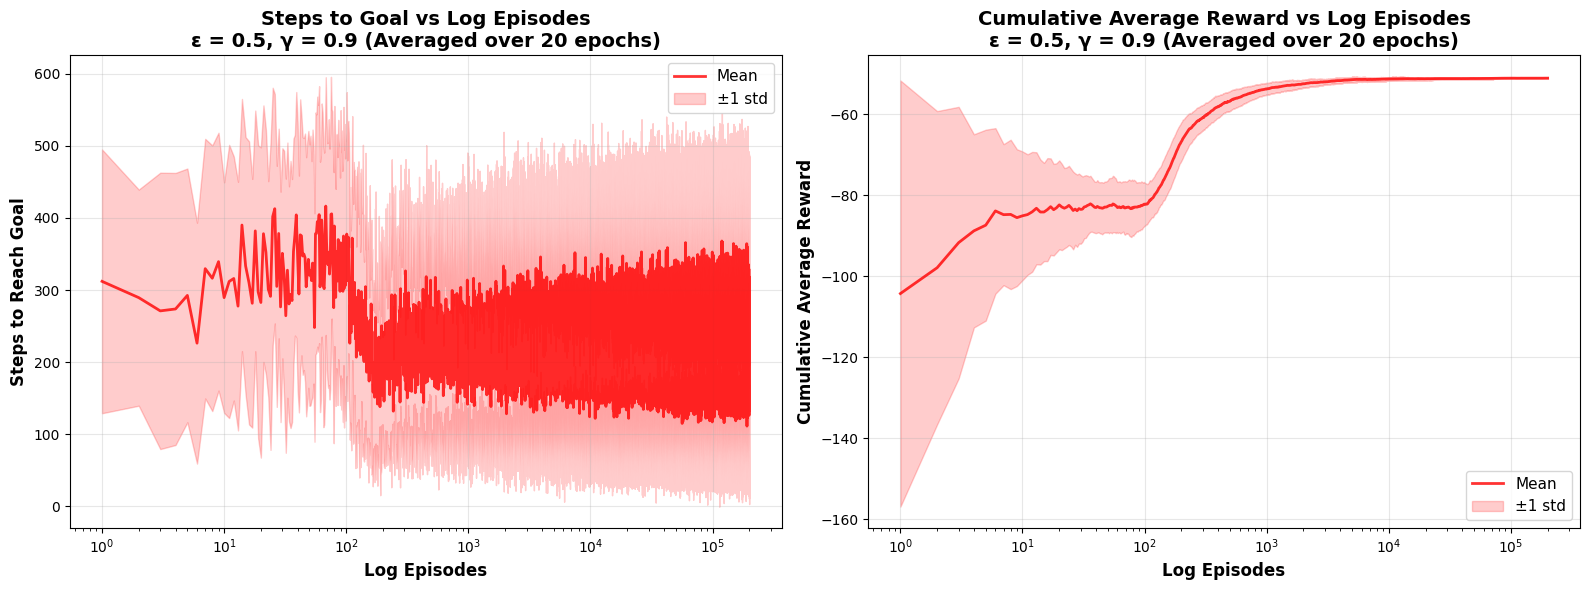


STATISTICS FOR ε = 0.5
Final Average Steps to Goal: 256.05 ± 133.66
Final Cumulative Avg Reward:  -51.0786 ± 0.0666
Minimum Steps (across all episodes): 111.45
Maximum Cumulative Reward: -51.0785



In [22]:
Qlearning.plot_epsilon_separate(results_bridge_q3_2, gamma=GAMMA_BRIDGE, episodes=NUM_EPISODES_BRIDGE)